# 02 – Tortuous Vessel CFD Analysis

**Case:** `openfoam/segment_test_V2`  
**Centerline:** `data/mr_limited/geometry/segment_test_centerline_candidate.vtu`  
**Surface:** `data/mr_limited/geometry/segment_test_surface.vtp`

This notebook characterises the CFD simulation of a tortuous vessel segment and
identifies where the idealised straight-pipe assumptions begin to break down.
All results are produced directly below each cell.
The extracted quantities form the input for the reduced-order models built in
`03_reduced_order_models_0D_1D.ipynb`.


## Section 1 – Geometry and Centerline Characterisation

The validated centerline candidate is loaded from the VTU file.
Coordinates are in **mm**; they are converted to **m** for all physical computations.
Radius arrays (`ce_radius`, `mis_radius`, `voreen_radius`) are stored as cell data
and represent three independent radius estimates:

| array | description |
| --- | --- |
| `ce_radius` | curvature-estimation (VMTK) radius |
| `mis_radius` | maximum inscribed sphere radius |
| `voreen_radius` | Voreen graph radius |


In [17]:
from pathlib import Path
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

%matplotlib inline

pd.set_option('display.precision', 6)
pd.set_option('display.max_columns', 20)

plt.rcParams.update({
    'figure.figsize': (7.2, 4.4),
    'axes.grid': True,
    'grid.alpha': 0.28,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.labelsize': 11,
    'axes.titlesize': 12,
    'legend.frameon': False,
})

REPO_ROOT = Path.cwd().resolve()
if REPO_ROOT.name == 'scripts':
    REPO_ROOT = REPO_ROOT.parent

CASE_DIR  = REPO_ROOT / 'openfoam' / 'segment_test_V2'
GEOM_DIR  = REPO_ROOT / 'data' / 'mr_limited' / 'geometry'
DATA_DIR  = CASE_DIR / 'data'
OUTPUT_DIR = REPO_ROOT / 'output' / 'segment_test_v2'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# ── physical constants ───────────────────────────────────────────────────────
rho = 1060.0        # kg/m^3  blood density
nu  = 3.3e-6        # m^2/s   kinematic viscosity (from transportProperties)
mu  = rho * nu      # Pa s    dynamic viscosity

print(f'Repository root : {REPO_ROOT}')
print(f'Case directory  : {CASE_DIR}')
print(f'Geometry dir    : {GEOM_DIR}')
print(f'rho = {rho} kg/m^3,  nu = {nu} m^2/s,  mu = {mu:.4e} Pa s')


Repository root : /home/gurovamr/OpenFOAM/gurovamr-dev/run/TrackModule2/Hemodynamics-Model-Comparison
Case directory  : /home/gurovamr/OpenFOAM/gurovamr-dev/run/TrackModule2/Hemodynamics-Model-Comparison/openfoam/segment_test_V2
Geometry dir    : /home/gurovamr/OpenFOAM/gurovamr-dev/run/TrackModule2/Hemodynamics-Model-Comparison/data/mr_limited/geometry
rho = 1060.0 kg/m^3,  nu = 3.3e-06 m^2/s,  mu = 3.4980e-03 Pa s


In [18]:
import vtk
from vtk.util.numpy_support import vtk_to_numpy
import networkx as nx

def load_centerline(path: Path):
    """Load a centerline VTU and return (points_mm, cell_data_dict, G)."""
    reader = vtk.vtkXMLUnstructuredGridReader()
    reader.SetFileName(str(path))
    reader.Update()
    data = reader.GetOutput()

    pts_mm = vtk_to_numpy(data.GetPoints().GetData())  # shape (N, 3), mm

    cell_data = {}
    cd = data.GetCellData()
    for i in range(cd.GetNumberOfArrays()):
        name = cd.GetArrayName(i)
        cell_data[name] = vtk_to_numpy(cd.GetArray(name))

    G = nx.Graph()
    for ci in range(data.GetNumberOfCells()):
        cell = data.GetCell(ci)
        p0 = cell.GetPointId(0)
        p1 = cell.GetPointId(1)
        seg_len_mm = float(np.linalg.norm(pts_mm[p1] - pts_mm[p0]))
        G.add_edge(p0, p1, length_mm=seg_len_mm, cell_idx=ci)

    return pts_mm, cell_data, G


cl_path = GEOM_DIR / 'segment_test_centerline_candidate.vtu'
pts_mm, cl_cell_data, G = load_centerline(cl_path)

ce_radius_mm  = cl_cell_data['ce_radius']
mis_radius_mm = cl_cell_data['mis_radius']
vor_radius_mm = cl_cell_data['voreen_radius']
labels        = cl_cell_data['labels']

print(f'Centerline points : {len(pts_mm)}')
print(f'Centerline cells  : {G.number_of_edges()}')
print(f'Unique labels     : {np.unique(labels)}')
print(f'Coordinate range  : {pts_mm.min(axis=0).round(3)} to {pts_mm.max(axis=0).round(3)} mm')


Centerline points : 126
Centerline cells  : 125
Unique labels     : [1 2 8]
Coordinate range  : [ -7.252 -34.405  -7.424] to [ 15.158 -16.494  -2.542] mm


In [19]:
# ── find terminal nodes (degree 1) ─────────────────────────────────────────
terminal_nodes = [n for n in G.nodes if G.degree(n) == 1]

# total arc length = sum of all edges (covers tree branches)
total_arc_length_mm = sum(data['length_mm'] for _, _, data in G.edges(data=True))

# straight distance between the two most separated terminal nodes
max_straight_mm = 0.0
inlet_node, outlet_node = terminal_nodes[0], terminal_nodes[-1]
for i, n1 in enumerate(terminal_nodes):
    for n2 in terminal_nodes[i + 1:]:
        d = float(np.linalg.norm(pts_mm[n1] - pts_mm[n2]))
        if d > max_straight_mm:
            max_straight_mm = d
            inlet_node, outlet_node = n1, n2

# path arc length along the main inlet-to-outlet route
main_path_nodes = nx.shortest_path(G, inlet_node, outlet_node)
main_path_arc_mm = sum(
    G[main_path_nodes[i]][main_path_nodes[i + 1]]['length_mm']
    for i in range(len(main_path_nodes) - 1)
)

tortuosity = main_path_arc_mm / max_straight_mm

# convert to metres for physical computations
cl_length_m   = main_path_arc_mm * 1e-3
straight_dist_m = max_straight_mm * 1e-3

geom_summary = pd.DataFrame({
    'quantity': [
        'main path arc length',
        'total tree arc length',
        'inlet-outlet straight distance',
        'tortuosity  T = arc / straight',
        'number of terminal nodes',
    ],
    'value': [
        round(main_path_arc_mm, 3),
        round(total_arc_length_mm, 3),
        round(max_straight_mm, 3),
        round(tortuosity, 4),
        len(terminal_nodes),
    ],
    'units': ['mm', 'mm', 'mm', '-', '-'],
})
display(geom_summary)

display(Markdown(
    f'**Tortuosity T = {tortuosity:.4f}.**  '
    f'A straight pipe has T = 1.0; values above 1 indicate increasing geometric '
    f'complexity. Here T ≈ {tortuosity:.2f}, meaning the vessel centerline is '
    f'{100*(tortuosity-1):.1f}% longer than the direct inlet-to-outlet line.'
))


,quantity,value,units
0,main path arc length,35.8930,mm
1,total tree arc length,36.7700,mm
2,inlet-outlet straight distance,25.2260,mm
3,tortuosity T = arc / straight,1.4228,-
4,number of terminal nodes,3.0000,-


**Tortuosity T = 1.4228.**  A straight pipe has T = 1.0; values above 1 indicate increasing geometric complexity. Here T ≈ 1.42, meaning the vessel centerline is 42.3% longer than the direct inlet-to-outlet line.

In [20]:
def radius_stats(arr_mm, name):
    return {
        'estimator': name,
        'mean_mm':   float(np.mean(arr_mm)),
        'median_mm': float(np.median(arr_mm)),
        'min_mm':    float(np.min(arr_mm)),
        'max_mm':    float(np.max(arr_mm)),
        'std_mm':    float(np.std(arr_mm)),
        'mean_m':    float(np.mean(arr_mm)) * 1e-3,
    }

radius_stats_df = pd.DataFrame([
    radius_stats(ce_radius_mm,  'ce_radius'),
    radius_stats(mis_radius_mm, 'mis_radius'),
    radius_stats(vor_radius_mm, 'voreen_radius'),
])

display(radius_stats_df)

# primary radius: ce_radius (used in all subsequent computations)
r_mean_m  = float(np.mean(ce_radius_mm)) * 1e-3
r_min_m   = float(np.min(ce_radius_mm))  * 1e-3
r_max_m   = float(np.max(ce_radius_mm))  * 1e-3

display(Markdown(
    f'**Primary estimator: `ce_radius`.**  '
    f'Mean = {r_mean_m*1e3:.3f} mm,  Min = {r_min_m*1e3:.3f} mm,  '
    f'Max = {r_max_m*1e3:.3f} mm.  '
    f'The ratio max/min = {r_max_m/r_min_m:.2f} indicates significant '
    f'variation in vessel radius along the centerline.'
))


,estimator,mean_mm,median_mm,min_mm,max_mm,std_mm,mean_m
0,ce_radius,1.102720,1.046847,0.711893,1.830107,0.208767,0.001103
1,mis_radius,0.914747,0.896402,0.483140,1.369759,0.177098,0.000915
2,voreen_radius,1.112824,1.095813,0.758858,1.609451,0.178642,0.001113


**Primary estimator: `ce_radius`.**  Mean = 1.103 mm,  Min = 0.712 mm,  Max = 1.830 mm.  The ratio max/min = 2.57 indicates significant variation in vessel radius along the centerline.

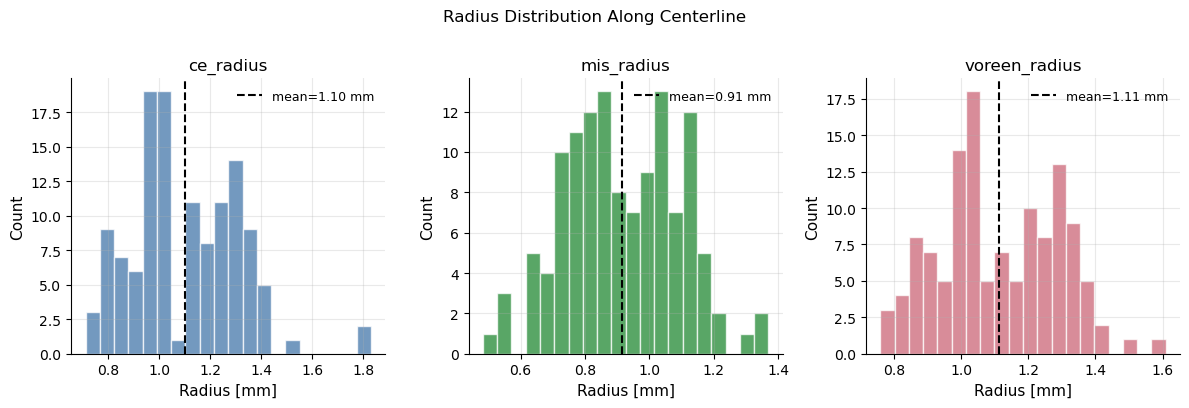

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4), sharey=False)

pairs = [
    (ce_radius_mm,  'ce_radius',     '#4477AA'),
    (mis_radius_mm, 'mis_radius',    '#228833'),
    (vor_radius_mm, 'voreen_radius', '#CC6677'),
]
for ax, (arr, name, color) in zip(axes, pairs):
    ax.hist(arr, bins=20, color=color, alpha=0.75, edgecolor='white')
    ax.axvline(np.mean(arr), color='black', linewidth=1.5,
               linestyle='--', label=f'mean={np.mean(arr):.2f} mm')
    ax.set_xlabel('Radius [mm]')
    ax.set_ylabel('Count')
    ax.set_title(name)
    ax.legend(fontsize=9)

fig.suptitle('Radius Distribution Along Centerline', y=1.01)
plt.tight_layout()
plt.show()


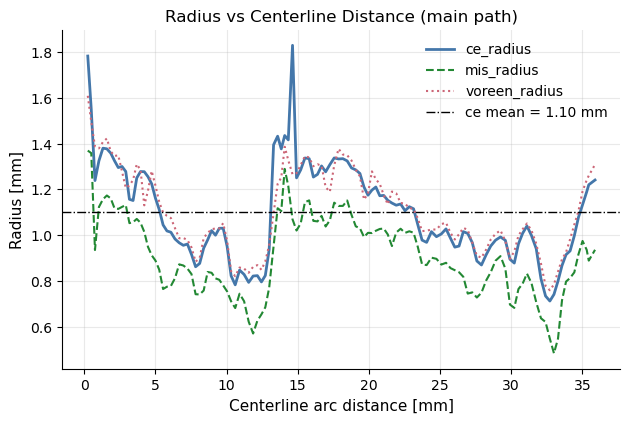

In [22]:
# Assign cumulative arc distance to each cell along the main path
main_path_edges = [
    (main_path_nodes[i], main_path_nodes[i + 1])
    for i in range(len(main_path_nodes) - 1)
]

arc_dist_mm = []
cell_indices = []
cum = 0.0
for p0, p1 in main_path_edges:
    seg = G[p0][p1]
    cum += seg['length_mm']
    arc_dist_mm.append(cum)
    cell_indices.append(seg['cell_idx'])

arc_dist_mm = np.array(arc_dist_mm)
cell_indices = np.array(cell_indices)

fig, ax = plt.subplots()
ax.plot(arc_dist_mm, ce_radius_mm[cell_indices],
        color='#4477AA', linewidth=2, label='ce_radius')
ax.plot(arc_dist_mm, mis_radius_mm[cell_indices],
        color='#228833', linewidth=1.5, linestyle='--', label='mis_radius')
ax.plot(arc_dist_mm, vor_radius_mm[cell_indices],
        color='#CC6677', linewidth=1.5, linestyle=':', label='voreen_radius')
ax.axhline(r_mean_m * 1e3, color='black', linewidth=1,
           linestyle='-.', label=f'ce mean = {r_mean_m*1e3:.2f} mm')
ax.set_xlabel('Centerline arc distance [mm]')
ax.set_ylabel('Radius [mm]')
ax.set_title('Radius vs Centerline Distance (main path)')
ax.legend()
plt.show()


### Geometry Discussion

The centerline provides the following information directly:

- **Arc length** along the main inlet–outlet path (equivalent to segment length for 1D models).
- **Local radius** at each cross-section, from three independent estimators.
- **Tortuosity** as the ratio of arc length to straight-line distance.

The radius is not constant: the vessel tapers and widens along its course,
with `ce_radius` showing the widest range. This variation means that a single
representative radius is only an approximation for any model that assumes uniform
cross-section.

The tortuosity value is available from geometry alone, **without running any CFD simulation**.
This is important: a reduced-order model could use T as a correction parameter
derived purely from the centerline geometry.


## Section 2 – CFD Data Loading

The CFD case (`segment_test_V2`) converged in 384 SIMPLE iterations.
No OpenFOAM `postProcessing` functions were active; instead, slice data
was exported from ParaView using **Integrate Variables** at three cross-sections:

| file | description |
| --- | --- |
| `inlet_integration_variable.csv` | integrated U and p at the inlet cross-section |
| `midslice_integration_variable.csv` | integrated U and p at a mid-vessel cross-section |
| `outlet_integration_variable.csv` | integrated U and p at the outlet cross-section |
| `network_resistance_table.csv` | pre-computed segment resistance table |

**ParaView Integrate Variables convention:**  
Each row contains the **area-weighted integral** of the field over the slice surface.  
- `U:0, U:1, U:2` → components of ∫∫ **U** dA [m³/s]  
- `p` → ∫∫ p dA [m²/s² · m²]  
- `Area` → slice area [m²]  

OpenFOAM incompressible solver stores pressure as **kinematic pressure** p [m²/s²].  
Physical pressure: P = ρ p  [Pa]


In [23]:
def load_integrated(path: Path) -> pd.Series:
    """Load a single-row ParaView Integrate Variables CSV."""
    df = pd.read_csv(path)
    if len(df) != 1:
        raise ValueError(f'Expected 1 row, got {len(df)} in {path}')
    return df.iloc[0]


iv_inlet  = load_integrated(DATA_DIR / 'inlet_integration_variable.csv')
iv_mid    = load_integrated(DATA_DIR / 'midslice_integration_variable.csv')
iv_outlet = load_integrated(DATA_DIR / 'outlet_integration_variable.csv')
net_res   = pd.read_csv(DATA_DIR / 'network_resistance_table.csv')

# ── display raw data ─────────────────────────────────────────────────────────
raw_summary = pd.DataFrame({
    'slice': ['inlet', 'midslice', 'outlet'],
    'U:0 [m^3/s]': [iv_inlet['U:0'], iv_mid['U:0'], iv_outlet['U:0']],
    'U:1 [m^3/s]': [iv_inlet['U:1'], iv_mid['U:1'], iv_outlet['U:1']],
    'U:2 [m^3/s]': [iv_inlet['U:2'], iv_mid['U:2'], iv_outlet['U:2']],
    'p_integral [m4/s2]': [iv_inlet['p'],    iv_mid['p'],    iv_outlet['p']],
    'Area [m^2]': [iv_inlet['Area'],  iv_mid['Area'],  iv_outlet['Area']],
})
display(raw_summary)

print('\nNetwork resistance table (pre-computed):')
display(net_res)


,slice,U:0 [m^3/s],U:1 [m^3/s],U:2 [m^3/s],p_integral [m4/s2],Area [m^2]
0,inlet,4.741272e-07,-9.003948e-07,-2.234622e-07,2.099549e-06,0.000005
1,midslice,6.732974e-07,-7.876472e-07,-6.125409e-08,9.406456e-07,0.000003
2,outlet,5.168782e-07,-8.832532e-07,1.435554e-07,4.822715e-07,0.000006



Network resistance table (pre-computed):


,label,arc_len_mm,r_mean_mm,R0_arith,R0_harm,R_1D,in_CFD_domain,R0_arith_mmHg,R0_harm_mmHg,R_1D_mmHg
0,1,18.24,2.1647,7.404033e+06,8.068109e+06,7.979322e+06,★,0.055535,0.060516,0.059850
1,2,36.12,1.0922,2.262308e+08,3.118441e+08,3.147469e+08,★,1.696875,2.339030,2.360802
2,3,33.52,1.4212,7.321240e+07,1.025850e+08,9.675240e+07,NaN,0.549140,0.769453,0.725705
3,4,31.92,2.3509,9.313189e+06,1.336008e+07,1.314141e+07,NaN,0.069855,0.100209,0.098569
4,5,17.81,1.9069,1.200255e+07,1.969210e+07,1.994574e+07,NaN,0.090027,0.147703,0.149606
5,6,32.71,2.3611,9.380338e+06,1.166613e+07,1.156423e+07,NaN,0.070359,0.087503,0.086739
6,7,16.91,1.8169,1.383135e+07,1.430908e+07,1.431106e+07,NaN,0.103744,0.107327,0.107342
7,8,6.61,1.4272,1.419617e+07,1.514488e+07,1.498230e+07,★,0.106480,0.113596,0.112377
8,9,10.19,0.4464,2.287638e+09,2.085378e+10,2.437826e+10,NaN,17.158741,156.416624,182.852466
9,10,1.68,1.8893,1.176556e+06,1.200076e+06,1.300060e+06,NaN,0.008825,0.009001,0.009751


## Section 3 – Pressure Analysis

Average kinematic pressure at each slice:
$$p_{\mathrm{avg}} = \frac{\int\!\int p\,\mathrm{d}A}{A}$$

Physical pressure: $P = \rho\, p_{\mathrm{avg}}$ [Pa]

Pressure drop: $\Delta P = P_{\mathrm{inlet}} - P_{\mathrm{outlet}}$ [Pa]

Average pressure gradient: $|{\nabla P}| = \Delta P / L_{\mathrm{arc}}$ [Pa/m]


In [24]:
def p_avg_pa(iv: pd.Series) -> float:
    """Area-averaged physical pressure from Integrate Variables row."""
    return rho * float(iv['p']) / float(iv['Area'])


p_inlet_pa  = p_avg_pa(iv_inlet)
p_mid_pa    = p_avg_pa(iv_mid)
p_outlet_pa = p_avg_pa(iv_outlet)

delta_p_pa        = p_inlet_pa - p_outlet_pa
pressure_gradient = delta_p_pa / cl_length_m    # Pa/m  (arc-length based)

pressure_summary = pd.DataFrame({
    'location': ['inlet', 'midslice', 'outlet'],
    'p_kinematic_avg [m^2/s^2]': [
        float(iv_inlet['p'])  / float(iv_inlet['Area']),
        float(iv_mid['p'])    / float(iv_mid['Area']),
        float(iv_outlet['p']) / float(iv_outlet['Area']),
    ],
    'P_physical [Pa]': [p_inlet_pa, p_mid_pa, p_outlet_pa],
    'P_physical [mmHg]': [
        p_inlet_pa  / 133.322,
        p_mid_pa    / 133.322,
        p_outlet_pa / 133.322,
    ],
})
display(pressure_summary)

pressure_drop_summary = pd.DataFrame({
    'quantity': [
        'P_inlet',
        'P_midslice',
        'P_outlet',
        'DeltaP = P_inlet - P_outlet',
        'DeltaP [mmHg]',
        'arc length L_arc',
        'average pressure gradient dP/ds',
    ],
    'value': [
        p_inlet_pa,
        p_mid_pa,
        p_outlet_pa,
        delta_p_pa,
        delta_p_pa / 133.322,
        cl_length_m,
        pressure_gradient,
    ],
    'units': ['Pa', 'Pa', 'Pa', 'Pa', 'mmHg', 'm', 'Pa/m'],
})
display(pressure_drop_summary)


,location,p_kinematic_avg [m^2/s^2],P_physical [Pa],P_physical [mmHg]
0,inlet,0.421050,446.313004,3.347632
1,midslice,0.303913,322.148230,2.416317
2,outlet,0.084856,89.947046,0.674660


,quantity,value,units
0,P_inlet,446.313004,Pa
1,P_midslice,322.148230,Pa
2,P_outlet,89.947046,Pa
3,DeltaP = P_inlet - P_outlet,356.365959,Pa
4,DeltaP [mmHg],2.672972,mmHg
5,arc length L_arc,0.035893,m
6,average pressure gradient dP/ds,9928.646332,Pa/m


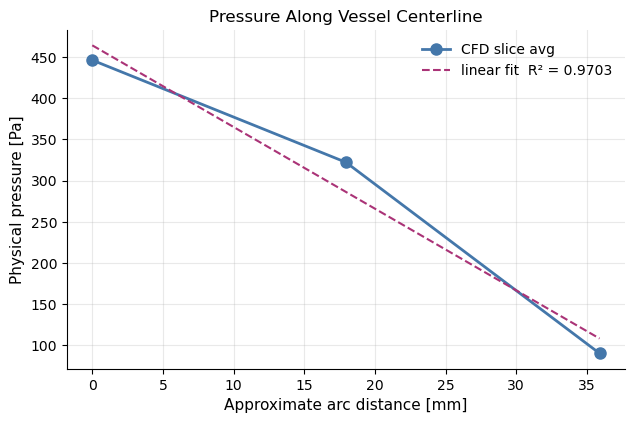

**Linearity check:** R² = 0.9703.  In a straight pipe with fully developed flow, pressure decreases linearly (R² → 1). In a tortuous vessel, local curvature, secondary flows, and cross-sectional area changes alter the pressure distribution; the R² value quantifies how much the three-slice pressure profile deviates from linearity.

In [25]:
# ── Pressure vs slice position ──────────────────────────────────────────────
# For three slices we use their approximate normalised positions:
#   inlet ≈ 0, midslice ≈ 0.5, outlet ≈ 1 (of arc length)
slice_positions_m = np.array([0.0, cl_length_m / 2.0, cl_length_m])
slice_pressures   = np.array([p_inlet_pa, p_mid_pa, p_outlet_pa])

# linear fit through three points
p_fit = np.polyfit(slice_positions_m, slice_pressures, 1)
p_fit_values = np.polyval(p_fit, slice_positions_m)

ss_res = np.sum((slice_pressures - p_fit_values) ** 2)
ss_tot = np.sum((slice_pressures - slice_pressures.mean()) ** 2)
p_r2   = 1 - ss_res / ss_tot if ss_tot > 0 else 1.0

fig, ax = plt.subplots()
ax.plot(slice_positions_m * 1e3, slice_pressures,
        'o-', color='#4477AA', linewidth=2, markersize=8, label='CFD slice avg')
ax.plot(slice_positions_m * 1e3, p_fit_values,
        '--', color='#AA3377', linewidth=1.5,
        label=f'linear fit  R² = {p_r2:.4f}')
ax.set_xlabel('Approximate arc distance [mm]')
ax.set_ylabel('Physical pressure [Pa]')
ax.set_title('Pressure Along Vessel Centerline')
ax.legend()
plt.show()

display(Markdown(
    f'**Linearity check:** R² = {p_r2:.4f}.  '
    'In a straight pipe with fully developed flow, pressure decreases linearly '
    '(R² → 1). In a tortuous vessel, local curvature, secondary flows, and '
    'cross-sectional area changes alter the pressure distribution; the R² value '
    'quantifies how much the three-slice pressure profile deviates from linearity.'
))


## Section 4 – Flow Analysis

Volumetric flow rate at each slice is computed as the **magnitude of the
integrated velocity vector**:

$$Q = \left|\int\!\int \mathbf{U}\,\mathrm{d}A\right|
      = \sqrt{\left(\int U_x\,\mathrm{d}A\right)^2 +
               \left(\int U_y\,\mathrm{d}A\right)^2 +
               \left(\int U_z\,\mathrm{d}A\right)^2}$$

This is valid when each slice is approximately perpendicular to the local
flow direction.  Flow conservation requires Q_inlet ≈ Q_mid ≈ Q_outlet.


In [26]:
def flow_rate(iv: pd.Series) -> float:
    """Volumetric flow rate [m^3/s] from Integrate Variables row."""
    return float(np.sqrt(iv['U:0']**2 + iv['U:1']**2 + iv['U:2']**2))


q_inlet  = flow_rate(iv_inlet)
q_mid    = flow_rate(iv_mid)
q_outlet = flow_rate(iv_outlet)

# mean velocity at each slice = Q / A
a_inlet  = float(iv_inlet['Area'])
a_mid    = float(iv_mid['Area'])
a_outlet = float(iv_outlet['Area'])

u_mean_inlet  = q_inlet  / a_inlet
u_mean_mid    = q_mid    / a_mid
u_mean_outlet = q_outlet / a_outlet

q_mean  = (q_inlet + q_mid + q_outlet) / 3.0
q_spread = 100.0 * (max(q_inlet, q_mid, q_outlet) -
                    min(q_inlet, q_mid, q_outlet)) / q_mean

flow_summary = pd.DataFrame({
    'location': ['inlet', 'midslice', 'outlet'],
    'Area [m^2]': [a_inlet, a_mid, a_outlet],
    'Q [m^3/s]': [q_inlet, q_mid, q_outlet],
    'Q [mL/s]': [q_inlet*1e6, q_mid*1e6, q_outlet*1e6],
    'U_mean [m/s]': [u_mean_inlet, u_mean_mid, u_mean_outlet],
    'relative to outlet [%]': [
        100*(q_inlet  - q_outlet)/q_outlet,
        100*(q_mid    - q_outlet)/q_outlet,
        0.0,
    ],
})
display(flow_summary)

display(pd.DataFrame({
    'check': ['Q spread across three slices'],
    'value [%]': [round(q_spread, 3)],
    'interpretation': ['< 5% supports mass conservation.'],
}))

display(Markdown(
    f'**Q_inlet = {q_inlet*1e6:.4f} mL/s,  '
    f'Q_mid = {q_mid*1e6:.4f} mL/s,  '
    f'Q_outlet = {q_outlet*1e6:.4f} mL/s.**  '
    f'Spread = {q_spread:.2f}%'
))


,location,Area [m^2],Q [m^3/s],Q [mL/s],U_mean [m/s],relative to outlet [%]
0,inlet,0.000005,0.000001,1.041846,0.208935,0.817674
1,midslice,0.000003,0.000001,1.038012,0.335372,0.446713
2,outlet,0.000006,0.000001,1.033396,0.181826,0.000000


,check,value [%],interpretation
0,Q spread across three slices,0.814,< 5% supports mass conservation.


**Q_inlet = 1.0418 mL/s,  Q_mid = 1.0380 mL/s,  Q_outlet = 1.0334 mL/s.**  Spread = 0.81%

## Section 5 – Hydraulic Resistance

**CFD resistance** from the simulation:
$$R_{\mathrm{CFD}} = \frac{\Delta P}{Q_{\mathrm{outlet}}}$$

**Poiseuille resistance** for a straight pipe with the centerline mean radius:
$$R_{\mathrm{Poiseuille}} = \frac{8\,\mu\,L}{\pi\,r^4}$$

The difference between $R_{\mathrm{CFD}}$ and $R_{\mathrm{Poiseuille}}$ captures
all effects not described by a uniform straight pipe: tortuosity, radius variation,
secondary flows, and entrance effects.

The pre-computed network table also provides segment resistances calculated
from the centerline geometry; these are compared below.


In [27]:
# ── CFD resistance ──────────────────────────────────────────────────────────
r_cfd = delta_p_pa / q_outlet

# ── Poiseuille resistance (mean ce_radius, main path arc length) ────────────
r_poiseuille = 8.0 * mu * cl_length_m / (np.pi * r_mean_m**4)

# ── Poiseuille with minimum radius (worst case) ─────────────────────────────
r_poiseuille_min_r = 8.0 * mu * cl_length_m / (np.pi * r_min_m**4)

pct_diff_mean_r = 100.0 * (r_cfd - r_poiseuille) / r_poiseuille

# ── network table: CFD-domain segment sum ───────────────────────────────────
cfd_segs = net_res[net_res['in_CFD_domain'].notna()].copy()
r_net_arith = float(cfd_segs['R0_arith'].sum())
r_net_harm  = float(cfd_segs['R0_harm'].sum())
r_net_1d    = float(cfd_segs['R_1D'].sum())

resistance_summary = pd.DataFrame({
    'model': [
        'R_CFD (ΔP/Q)',
        'R_Poiseuille (mean r, arc L)',
        'R_Poiseuille (min r, arc L)',
        'R_network arith (Σ segments)',
        'R_network harm  (Σ segments)',
        'R_network 1D    (Σ segments)',
    ],
    'R [Pa s/m^3]': [
        r_cfd,
        r_poiseuille,
        r_poiseuille_min_r,
        r_net_arith,
        r_net_harm,
        r_net_1d,
    ],
    'R [mmHg s/mL]': [
        r_cfd   * 1e-6 / 133.322,
        r_poiseuille * 1e-6 / 133.322,
        r_poiseuille_min_r * 1e-6 / 133.322,
        r_net_arith * 1e-6 / 133.322,
        r_net_harm  * 1e-6 / 133.322,
        r_net_1d    * 1e-6 / 133.322,
    ],
})
display(resistance_summary)

display(pd.DataFrame({
    'comparison': [
        'R_CFD vs R_Poiseuille (mean r)',
        'R_CFD vs R_network_1D',
    ],
    'abs diff [Pa s/m^3]': [
        abs(r_cfd - r_poiseuille),
        abs(r_cfd - r_net_1d),
    ],
    'pct diff [%]': [
        pct_diff_mean_r,
        100*(r_cfd - r_net_1d)/r_net_1d,
    ],
}))

display(Markdown(
    f'**Key result:** R_CFD = {r_cfd:.3e} Pa s/m³.  '
    f'Poiseuille formula with mean radius over-estimates/under-estimates by '
    f'{pct_diff_mean_r:+.1f}%.  '
    'Length and mean radius alone do **not** fully explain CFD resistance;  '
    'tortuosity, local radius variation, and secondary flows contribute additional '
    'momentum loss.'
))


,model,R [Pa s/m^3],R [mmHg s/mL]
0,R_CFD (ΔP/Q),3.448494e+08,2.586590
1,"R_Poiseuille (mean r, arc L)",2.162244e+08,1.621821
2,"R_Poiseuille (min r, arc L)",1.244824e+09,9.336974
3,R_network arith (Σ segments),2.478310e+08,1.858891
4,R_network harm (Σ segments),3.350571e+08,2.513142
5,R_network 1D (Σ segments),3.377085e+08,2.533029


,comparison,abs diff [Pa s/m^3],pct diff [%]
0,R_CFD vs R_Poiseuille (mean r),1.286250e+08,59.486803
1,R_CFD vs R_network_1D,7.140868e+06,2.114506


**Key result:** R_CFD = 3.448e+08 Pa s/m³.  Poiseuille formula with mean radius over-estimates/under-estimates by +59.5%.  Length and mean radius alone do **not** fully explain CFD resistance;  tortuosity, local radius variation, and secondary flows contribute additional momentum loss.

## Section 6 – Velocity Profile Analysis

This section characterises the velocity field at three cross-sections.

**§ 6.1 – Cross-section mean statistics** (Q/A-based):  
Mean velocity, Reynolds number, and Dean number are derived from the volumetric flow
rate and slice area.  These scalars summarise *how fast* the fluid moves.

**§ 6.2 – Per-point velocity distribution** (ParaView point-CSV):  
The $U_{\max}/U_{\mathrm{mean}}$ ratio and secondary-flow fraction are computed from
point-wise velocity data at each slice, characterising *how the profile deviates
from the parabolic Poiseuille shape*.

For a straight Hagen–Poiseuille flow:
- $U_{\max}/U_{\mathrm{mean}} = 2$
- Secondary flow ≈ 0

In a tortuous vessel, curvature redistributes momentum, flattening and skewing the
axial profile and generating transverse velocity components.

Reynolds number: $\mathrm{Re} = U D / \nu$  
Dean number: $\mathrm{De} = \mathrm{Re}\,\sqrt{r / R_c}$  
where $D = 2r$ is the hydraulic diameter and $R_c$ is the radius of curvature.


,location,A [m^2],Q [m^3/s],U_mean [m/s],Re
0,inlet,0.000005,0.000001,0.208935,139.634454
1,midslice,0.000003,0.000001,0.335372,224.134025
2,outlet,0.000006,0.000001,0.181826,121.517164


,quantity,value
0,mean velocity (outlet),0.1818 m/s
1,mean hydraulic diameter,2.205 mm
2,Reynolds number (outlet),121.5
3,flow regime assessment,Laminar (Re < 2300)


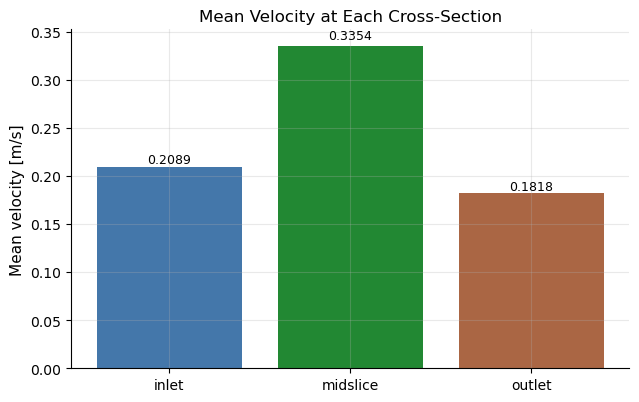

**Re = 121.5** (laminar regime).  In a tortuous vessel, even at low Re, curvature-induced secondary flows (Dean vortices) develop, flattening and skewing the axial velocity profile.  The mean velocity varies between cross-sections partly because the slice areas differ (vessel is not uniform), and partly due to real three-dimensional flow redistribution.

In [28]:
# Use outlet conditions as the primary reference
d_mean_m  = 2.0 * r_mean_m       # hydraulic diameter [m]

re_inlet  = u_mean_inlet  * d_mean_m / nu
re_mid    = u_mean_mid    * d_mean_m / nu
re_outlet = u_mean_outlet * d_mean_m / nu

velocity_summary = pd.DataFrame({
    'location':        ['inlet',       'midslice',    'outlet'],
    'A [m^2]':         [a_inlet,        a_mid,         a_outlet],
    'Q [m^3/s]':       [q_inlet,        q_mid,         q_outlet],
    'U_mean [m/s]':    [u_mean_inlet,   u_mean_mid,    u_mean_outlet],
    'Re':              [re_inlet,        re_mid,         re_outlet],
})
display(velocity_summary)

velocity_stats = pd.DataFrame({
    'quantity': [
        'mean velocity (outlet)',
        'mean hydraulic diameter',
        'Reynolds number (outlet)',
        'flow regime assessment',
    ],
    'value': [
        f'{u_mean_outlet:.4f} m/s',
        f'{d_mean_m*1e3:.3f} mm',
        f'{re_outlet:.1f}',
        'Laminar (Re < 2300)' if re_outlet < 2300 else 'Transitional/Turbulent',
    ],
})
display(velocity_stats)

fig, ax = plt.subplots()
locs = ['inlet', 'midslice', 'outlet']
u_means = [u_mean_inlet, u_mean_mid, u_mean_outlet]
ax.bar(locs, u_means, color=['#4477AA', '#228833', '#AA6644'])
ax.set_ylabel('Mean velocity [m/s]')
ax.set_title('Mean Velocity at Each Cross-Section')
for i, v in enumerate(u_means):
    ax.text(i, v * 1.02, f'{v:.4f}', ha='center', fontsize=9)
plt.show()

display(Markdown(
    f'**Re = {re_outlet:.1f}** (laminar regime).  '
    'In a tortuous vessel, even at low Re, curvature-induced secondary flows '
    '(Dean vortices) develop, flattening and skewing the axial velocity profile.  '
    'The mean velocity varies between cross-sections partly because the slice '
    'areas differ (vessel is not uniform), and partly due to real three-dimensional '
    'flow redistribution.'
))


### § 6.2 – Per-Point Velocity Distribution

Per-point velocity fields exported from ParaView (**Clip at each cross-section**, then
saved as point-wise CSV) are used to compute the velocity distribution shape at each slice.
Each file contains one row per mesh cell on the slice.

**Computed quantities:**
- $U_{\max}/U_{\mathrm{mean}}$ ratio — deviation from the Poiseuille value of 2.0
- **Secondary flow ratio** $= \bar{U}_\perp / \bar{U}_{\mathrm{axial}}$ — mean transverse
  velocity relative to the axial component
- Velocity-magnitude histograms at each cross-section

The local vessel axis at each slice is estimated from finite differences of the ordered
centerline point coordinates (computed locally; does not depend on the curvature section).

> **Interpretation note:** The secondary-flow ratio depends on the accuracy of the
> slice-normal / centerline-tangent alignment.  Values should be interpreted qualitatively,
> particularly when the ratio exceeds 1.0.


In [ ]:
def load_slice_pts(path: Path) -> pd.DataFrame:
    """Load per-point slice CSV (no coordinates; U:0/1/2 and p columns)."""
    df = pd.read_csv(path)
    df.columns = df.columns.str.strip().str.replace('"', '')
    df['Umag'] = np.sqrt(df['U:0']**2 + df['U:1']**2 + df['U:2']**2)
    return df


def slice_velocity_stats(df: pd.DataFrame, label: str, tangent: np.ndarray) -> dict:
    """
    Compute velocity statistics for a point-wise slice DataFrame.
    tangent: unit vector along the local vessel axis at this slice.
    """
    uvec = df[['U:0', 'U:1', 'U:2']].values   # (N, 3)
    umag = df['Umag'].values

    # axial component: projection onto tangent
    u_axial = np.abs(uvec @ tangent)
    # secondary: magnitude of transverse component
    u_sec   = np.sqrt(np.maximum(umag**2 - u_axial**2, 0))

    u_mean      = float(np.mean(u_axial))
    u_max       = float(np.max(u_axial))
    u_max_ratio = u_max / u_mean if u_mean > 1e-10 else np.nan
    sec_ratio   = float(np.mean(u_sec)) / u_mean if u_mean > 1e-10 else np.nan

    return {
        'slice':                 label,
        'N_pts':                 len(df),
        'U_axial_mean':          u_mean,
        'U_axial_max':           u_max,
        'Umax/Umean':            u_max_ratio,
        'U_sec_mean':            float(np.mean(u_sec)),
        'sec_flow_ratio':        sec_ratio,
        'Poiseuille_Umax/Umean': 2.0,
        'excess_peak_factor':    u_max_ratio / 2.0 if not np.isnan(u_max_ratio) else np.nan,
    }


# ── Load slice point data ─────────────────────────────────────────────────────
sl_inlet  = load_slice_pts(DATA_DIR / 'inlet_integration.csv')
sl_mid    = load_slice_pts(DATA_DIR / 'midslice_integration.csv')
sl_outlet = load_slice_pts(DATA_DIR / 'outlet_integration.csv')

# ── Estimate tangent at each slice from ordered main-path centerline ──────────
# Uses finite differences on path node positions; does NOT depend on curv.
_pts_ord        = pts_mm[main_path_nodes]
_diffs          = np.diff(_pts_ord, axis=0)
_norms          = np.linalg.norm(_diffs, axis=1, keepdims=True)
_tangents_local = _diffs / (_norms + 1e-12)

t_inlet  = _tangents_local[0]
t_mid    = _tangents_local[len(_tangents_local) // 2]
t_outlet = _tangents_local[-1]

stats = [
    slice_velocity_stats(sl_inlet,  'inlet',    t_inlet),
    slice_velocity_stats(sl_mid,    'midslice', t_mid),
    slice_velocity_stats(sl_outlet, 'outlet',   t_outlet),
]
vel_profile_df = pd.DataFrame(stats)
display(vel_profile_df)

# ── Plot: Umax/Umean deviation from Poiseuille ────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

slices     = ['inlet', 'midslice', 'outlet']
ratio_vals = vel_profile_df['Umax/Umean'].values
sec_vals   = vel_profile_df['sec_flow_ratio'].values

axes[0].bar(slices, ratio_vals, color=['#4477AA', '#228833', '#AA6644'])
axes[0].axhline(2.0, color='black', linewidth=1.5, linestyle='--', label='Poiseuille = 2.0')
axes[0].set_ylabel('Umax / Umean')
axes[0].set_title('Peak-to-Mean Velocity Ratio (axial)')
axes[0].legend()
for i, v in enumerate(ratio_vals):
    axes[0].text(i, v + 0.02, f'{v:.3f}', ha='center', fontsize=9)

axes[1].bar(slices, sec_vals * 100, color=['#4477AA', '#228833', '#AA6644'])
axes[1].set_ylabel('Secondary flow ratio [%]')
axes[1].set_title('Secondary / Axial Velocity Ratio')
for i, v in enumerate(sec_vals):
    axes[1].text(i, v * 100 + 0.3, f'{v*100:.1f}%', ha='center', fontsize=9)
plt.tight_layout()
plt.show()

# ── Distributions: velocity magnitude histograms ─────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(12, 4), sharey=False)
for ax, (sl, lbl, col) in zip(axes, [
        (sl_inlet,  'inlet',    '#4477AA'),
        (sl_mid,    'midslice', '#228833'),
        (sl_outlet, 'outlet',   '#AA6644'),
]):
    ax.hist(sl['Umag'], bins=40, color=col, alpha=0.75, edgecolor='white')
    ax.axvline(sl['Umag'].mean(), color='black', linewidth=1.5, linestyle='--',
               label=f'mean={sl["Umag"].mean():.3f} m/s')
    ax.set_xlabel('|U| [m/s]')
    ax.set_ylabel('Count')
    ax.set_title(f'Velocity distribution – {lbl}')
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

# ── Warn if secondary-flow ratio exceeds 1.0 ─────────────────────────────────
_sec_warning = ''
if any(s > 1.0 for s in sec_vals):
    _sec_warning = (
        '  ⚠ **One or more secondary-flow ratios exceed 1.0.**  '
        'This likely reflects imperfect slice-normal / centerline-tangent alignment '
        'rather than a physically larger transverse than axial velocity component.  '
        'Values should be interpreted qualitatively.'
    )

display(Markdown(
    '**Velocity profile analysis.**  '
    f'Inlet Umax/Umean = {ratio_vals[0]:.3f} (Poiseuille = 2.0); '
    f'midslice = {ratio_vals[1]:.3f}; '
    f'outlet = {ratio_vals[2]:.3f}.  '
    'Values deviating from 2.0 indicate a non-parabolic axial profile consistent with '
    'developing-flow entrance effects and curvature-driven flow redistribution.  '
    f'Secondary flow ratio: inlet = {sec_vals[0]*100:.1f}%, '
    f'midslice = {sec_vals[1]*100:.1f}%, '
    f'outlet = {sec_vals[2]*100:.1f}%.  '
    'The metric indicates significant non-axial velocity components, but the magnitude '
    'depends on slice-normal and centerline-tangent alignment and should be interpreted '
    'qualitatively.' + _sec_warning
))


## Section 7 – Wall Shear Stress

The OpenFOAM case did not include a `wallShearStress` post-processing function,
so WSS is estimated analytically from the available pressure and flow data.

For a straight circular pipe (reference):
$$\tau_w = \frac{4\,\mu\,Q}{\pi\,R^3} = \frac{\Delta P\,R}{2\,L}$$

In a tortuous vessel the **local** WSS depends on curvature.  
The outer wall of a curved section experiences higher shear than the inner wall;
the degree of asymmetry scales with the Dean number:
$$\mathrm{De} = \mathrm{Re}\,\sqrt{\frac{r}{R_c}}$$
where $r$ is the vessel radius and $R_c$ is the radius of curvature.

Here we compute the **effective global WSS** from the pressure drop and geometry
as a scalar summary.  Spatial WSS heterogeneity requires the full 3D wall field
from OpenFOAM, which is not available in this run.


In [29]:
# ── Analytical WSS estimates ─────────────────────────────────────────────────
tau_w_from_q   = 4.0 * mu * q_outlet / (np.pi * r_mean_m**3)   # Pa
tau_w_from_dp  = delta_p_pa * r_mean_m / (2.0 * cl_length_m)    # Pa

# ── Straight-pipe reference using the same flow rate (from notebook 01) ──────
# Load straight-pipe wss summary if it exists for direct comparison
pipe_wss_path = REPO_ROOT / 'output' / 'pipe_v2' / 'straight_pipe_wss_summary.csv'
tau_w_straight_pipe = None
if pipe_wss_path.exists():
    pipe_wss_df = pd.read_csv(pipe_wss_path)
    row = pipe_wss_df[pipe_wss_df['quantity'] == 'tau_w_CFD_physical']
    if not row.empty:
        tau_w_straight_pipe = float(row['value'].iloc[0])

# ── Dean number estimate ─────────────────────────────────────────────────────
# Approximate radius of curvature from tortuosity and arc length
# For a sinusoidal path: R_c ~ L^2 / (8 * delta) where delta = L - L_straight
# Conservative geometric estimate using: R_c_est = straight_dist_m / (2*(T-1)+eps)
eps = 1e-10
r_curvature_est = straight_dist_m / (2.0 * max(tortuosity - 1.0, eps))
dean_number = re_outlet * np.sqrt(r_mean_m / r_curvature_est)

wss_summary = pd.DataFrame({
    'quantity': [
        'tau_w from Q (Hagen-Poiseuille)',
        'tau_w from DeltaP (effective)',
        'tau_w straight-pipe reference',
        'Dean number estimate',
        'Estimated radius of curvature',
    ],
    'value': [
        tau_w_from_q,
        tau_w_from_dp,
        tau_w_straight_pipe if tau_w_straight_pipe is not None else float('nan'),
        dean_number,
        r_curvature_est * 1e3,
    ],
    'units': ['Pa', 'Pa', 'Pa', '-', 'mm'],
})
display(wss_summary)

display(Markdown(
    f'**Effective tau_w ≈ {tau_w_from_q:.4f} Pa** (Q-based estimate).  '
    f'Dean number De ≈ {dean_number:.2f}.  '
    'For De > ~10, secondary flow effects become significant, producing '
    'wall-shear heterogeneity.  Even at low De the outer-wall WSS in a curved '
    'vessel exceeds the inner-wall WSS by factors that grow with curvature.  '
    'The scalar WSS reported here is the equivalent straight-pipe value; it '
    'under-represents the local peak WSS that would occur on the outer wall of '
    'each bend.'
))


,quantity,value,units
0,tau_w from Q (Hagen-Poiseuille),3.432422,Pa
1,tau_w from DeltaP (effective),5.474260,Pa
2,tau_w straight-pipe reference,0.711934,Pa
3,Dean number estimate,23.363342,-
4,Estimated radius of curvature,29.831196,mm


**Effective tau_w ≈ 3.4324 Pa** (Q-based estimate).  Dean number De ≈ 23.36.  For De > ~10, secondary flow effects become significant, producing wall-shear heterogeneity.  Even at low De the outer-wall WSS in a curved vessel exceeds the inner-wall WSS by factors that grow with curvature.  The scalar WSS reported here is the equivalent straight-pipe value; it under-represents the local peak WSS that would occur on the outer wall of each bend.

## Section 8 – Continuous Centerline Pressure Sampling

The inlet/mid/outlet pressure from ParaView slices (Section 3) gives only three
scalar values. Here the OpenFOAM CFD fields are probed directly onto every
centerline point using `vtkProbeFilter`, producing a continuous pressure profile
$P(s)$ along the arc distance $s$.

**Key quantities extracted:**
- $P(s)$ — physical pressure at each centerline point [Pa]
- $\mathrm{d}P/\mathrm{d}s$ — local pressure gradient along the path [Pa/m]
- Linear-fit R² — deviation from straight-pipe (constant-gradient) decay
- RMSE from linear decay — absolute non-linearity amplitude [Pa]
- Location of peak pressure gradient — where most resistance is concentrated

**Unit conventions:**
- Centerline coordinates are in mm; scaled to m for probing.
- OpenFOAM kinematic pressure $p$ [m²/s²] → physical pressure $P = \rho p$ [Pa].

**Probing validity:**  
Not all centerline points lie within the CFD mesh, so `vtkProbeFilter` marks
invalid query points with `vtkValidPointMask = 0`.  Invalid points may arise from:

- **Domain mismatch** — the centerline file includes side branches not present in the
  CFD geometry; only the main vessel segment is simulated.
- **Mesh boundary gaps** — points very close to, or just outside, the convex hull of
  the CFD mesh are excluded.
- **Coordinate registration** — the centerline is in mm; a residual scaling or
  alignment error would shift points outside the domain.
- **Probe interpolation limits** — `vtkProbeFilter` locates each query point via
  cell search; the first and last points of the path may fall just outside the
  inlet/outlet boundary faces.

The valid fraction (valid points / total centerline points) is reported in the
summary table (Section 13).


In [30]:
def load_cfd_fields(foam_file: str, time_step: float = 384.0):
    """
    Load OpenFOAM cell fields at a given time step.
    Returns vtkUnstructuredGrid with point-data arrays (after cell→point interp).
    """
    reader = vtk.vtkOpenFOAMReader()
    reader.SetFileName(foam_file)
    reader.UpdateInformation()
    executive = reader.GetExecutive()
    out_info  = executive.GetOutputInformation(0)
    out_info.Set(
        vtk.vtkStreamingDemandDrivenPipeline.UPDATE_TIME_STEP(), time_step
    )
    executive.Update()
    cfd_block = reader.GetOutput().GetBlock(0)

    c2p = vtk.vtkCellDataToPointData()
    c2p.SetInputData(cfd_block)
    c2p.Update()
    return c2p.GetOutput()


def probe_cfd_onto_points(cfd_pt_data, query_pts_mm: np.ndarray) -> dict:
    """
    Probe vtkUnstructuredGrid (with point data) at query_pts_mm [mm].
    Returns dict with 'p', 'U', 'valid' numpy arrays.
    """
    probe_pd = vtk.vtkPolyData()
    pts_vtk  = vtk.vtkPoints()
    pts_vtk.SetData(
        vtk.util.numpy_support.numpy_to_vtk(query_pts_mm * 1e-3, deep=True)
    )
    probe_pd.SetPoints(pts_vtk)

    probe = vtk.vtkProbeFilter()
    probe.SetInputData(probe_pd)
    probe.SetSourceData(cfd_pt_data)
    probe.Update()
    result = probe.GetOutput()

    valid = vtk_to_numpy(result.GetPointData().GetArray('vtkValidPointMask')).astype(bool)
    p_kin = vtk_to_numpy(result.GetPointData().GetArray('p'))
    u_vec = vtk_to_numpy(result.GetPointData().GetArray('U'))
    return {'p_kinematic': p_kin, 'U': u_vec, 'valid': valid}


# ── Load CFD fields ──────────────────────────────────────────────────────────
foam_file = str(CASE_DIR / 'segment_test.foam')
cfd_pt = load_cfd_fields(foam_file, time_step=384.0)
print('CFD point-data arrays:', [cfd_pt.GetPointData().GetArrayName(i)
                                  for i in range(cfd_pt.GetPointData().GetNumberOfArrays())])

# ── Probe onto ordered main-path centerline points ───────────────────────────
# main_path_nodes is ordered inlet→outlet; extract their coordinates
main_path_pts_mm = pts_mm[main_path_nodes]   # shape (N_path, 3)
probed = probe_cfd_onto_points(cfd_pt, main_path_pts_mm)

valid     = probed['valid']
p_kin_raw = probed['p_kinematic']
u_raw     = probed['U']

# physical pressure [Pa]
p_phys_raw = rho * p_kin_raw

# ── Build arc-distance array for main path ───────────────────────────────────
n_path = len(main_path_nodes)
arc_s_raw = np.zeros(n_path)
for k in range(1, n_path):
    arc_s_raw[k] = arc_s_raw[k-1] + np.linalg.norm(
        pts_mm[main_path_nodes[k]] - pts_mm[main_path_nodes[k-1]]
    )  # mm

# Keep only valid probed points
mask      = valid
arc_s_mm  = arc_s_raw[mask]
p_phys    = p_phys_raw[mask]
u_vecs    = u_raw[mask]
umag      = np.linalg.norm(u_vecs, axis=1)

n_valid = mask.sum()
print(f'Valid probed centerline points: {n_valid} / {n_path}')
print(f'Arc range: {arc_s_mm.min():.2f} – {arc_s_mm.max():.2f} mm')
print(f'P range:   {p_phys.min():.2f} – {p_phys.max():.2f} Pa')
print(f'U mag:     {umag.min():.4f} – {umag.max():.4f} m/s')


CFD point-data arrays: ['U', 'p']
Valid probed centerline points: 65 / 124
Arc range: 16.39 – 35.89 mm
P range:   67.04 – 503.59 Pa
U mag:     0.1037 – 0.8592 m/s


,quantity,value,units
0,P min (centerline),67.037651,Pa
1,P max (centerline),503.589630,Pa
2,P drop (max-min),436.551971,Pa
3,mean dP/ds,-20363.632812,Pa/m
4,max |dP/ds|,125186.226562,Pa/m
5,arc position of peak |dP/ds|,32.093385,mm
6,linear fit R²,0.937480,-
7,RMSE from linear decay,34.233681,Pa
8,N valid centerline points,65.000000,-


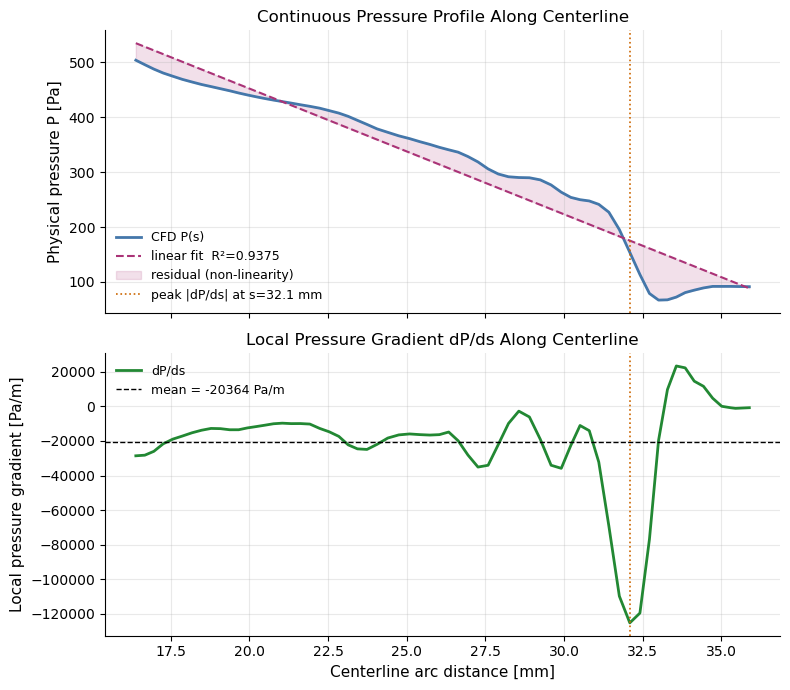

**Continuous pressure analysis: R² = 0.9375, RMSE = 34.23 Pa.**  A straight pipe would yield R² → 1 with negligible RMSE.  Deviations indicate where local geometry alters the pressure field beyond the mean-gradient prediction.  The peak pressure gradient occurs at arc position s = 32.1 mm, where local curvature or narrowing concentrates viscous losses.

In [31]:
# ── Linear fit to P(s) ──────────────────────────────────────────────────────
arc_s_m = arc_s_mm * 1e-3

p_fit_cont   = np.polyfit(arc_s_m, p_phys, 1)
p_fit_line   = np.polyval(p_fit_cont, arc_s_m)
p_residuals  = p_phys - p_fit_line

ss_res_cont = np.sum(p_residuals**2)
ss_tot_cont = np.sum((p_phys - p_phys.mean())**2)
p_r2_cont   = 1 - ss_res_cont / ss_tot_cont if ss_tot_cont > 0 else 1.0
p_rmse_cont = float(np.sqrt(np.mean(p_residuals**2)))

# ── Local pressure gradient dP/ds ───────────────────────────────────────────
dp_ds = np.gradient(p_phys, arc_s_m)   # Pa/m

# Location of peak |dP/ds|
idx_peak_dp = int(np.argmax(np.abs(dp_ds)))
s_peak_dp   = arc_s_mm[idx_peak_dp]

# ── Summary ──────────────────────────────────────────────────────────────────
cl_pressure_summary = pd.DataFrame({
    'quantity': [
        'P min (centerline)',
        'P max (centerline)',
        'P drop (max-min)',
        'mean dP/ds',
        'max |dP/ds|',
        'arc position of peak |dP/ds|',
        'linear fit R²',
        'RMSE from linear decay',
        'N valid centerline points',
    ],
    'value': [
        p_phys.min(),
        p_phys.max(),
        p_phys.max() - p_phys.min(),
        float(np.mean(dp_ds)),
        float(np.max(np.abs(dp_ds))),
        s_peak_dp,
        p_r2_cont,
        p_rmse_cont,
        n_valid,
    ],
    'units': ['Pa', 'Pa', 'Pa', 'Pa/m', 'Pa/m', 'mm', '-', 'Pa', '-'],
})
display(cl_pressure_summary)

# ── Plots ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(8, 7), sharex=True)

axes[0].plot(arc_s_mm, p_phys, color='#4477AA', linewidth=2, label='CFD P(s)')
axes[0].plot(arc_s_mm, p_fit_line, '--', color='#AA3377', linewidth=1.5,
             label=f'linear fit  R²={p_r2_cont:.4f}')
axes[0].fill_between(arc_s_mm, p_fit_line, p_phys, alpha=0.15, color='#AA3377',
                     label='residual (non-linearity)')
axes[0].axvline(s_peak_dp, color='#CC6600', linewidth=1.2, linestyle=':',
                label=f'peak |dP/ds| at s={s_peak_dp:.1f} mm')
axes[0].set_ylabel('Physical pressure P [Pa]')
axes[0].set_title('Continuous Pressure Profile Along Centerline')
axes[0].legend(fontsize=9)

axes[1].plot(arc_s_mm, dp_ds, color='#228833', linewidth=2, label='dP/ds')
axes[1].axhline(np.mean(dp_ds), color='black', linewidth=1, linestyle='--',
                label=f'mean = {np.mean(dp_ds):.0f} Pa/m')
axes[1].axvline(s_peak_dp, color='#CC6600', linewidth=1.2, linestyle=':')
axes[1].set_xlabel('Centerline arc distance [mm]')
axes[1].set_ylabel('Local pressure gradient [Pa/m]')
axes[1].set_title('Local Pressure Gradient dP/ds Along Centerline')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

display(Markdown(
    f'**Continuous pressure analysis: R² = {p_r2_cont:.4f}, RMSE = {p_rmse_cont:.2f} Pa.**  '
    f'A straight pipe would yield R² → 1 with negligible RMSE.  '
    f'Deviations indicate where local geometry alters the pressure field beyond '
    f'the mean-gradient prediction.  '
    f'The peak pressure gradient occurs at arc position s = {s_peak_dp:.1f} mm, '
    f'where local curvature or narrowing concentrates viscous losses.'
))


## Section 9 – Centerline Curvature Analysis

Local curvature $\kappa(s)$ is computed from the Frenet formula along the
ordered centerline path:

$$\kappa = \frac{|\mathbf{T}' \times \mathbf{T}|}{|\Delta s|}
\approx \frac{|\mathbf{r}''|}{1}$$

where $\mathbf{T} = \mathrm{d}\mathbf{r}/\mathrm{d}s$ is the unit tangent
and $\mathbf{r}$ is the position vector.

The radius of curvature is $R_c = 1/\kappa$.

**Extracted quantities:**
- $\kappa(s)$, $R_c(s)$ — local curvature and radius of curvature along the path
- Mean, max, std of curvature
- Overlay of $\kappa(s)$ and $|dP/ds|$ to test spatial correlation
- Correlation coefficient between curvature and pressure gradient magnitude


,quantity,value,units
0,mean curvature κ_mean,0.266895,1/mm
1,max curvature κ_max,1.249540,1/mm
2,std curvature κ_std,0.231430,1/mm
3,arc position of κ_max,14.086544,mm
4,min finite Rc,0.800294,mm
5,mean finite Rc,7.806625,mm


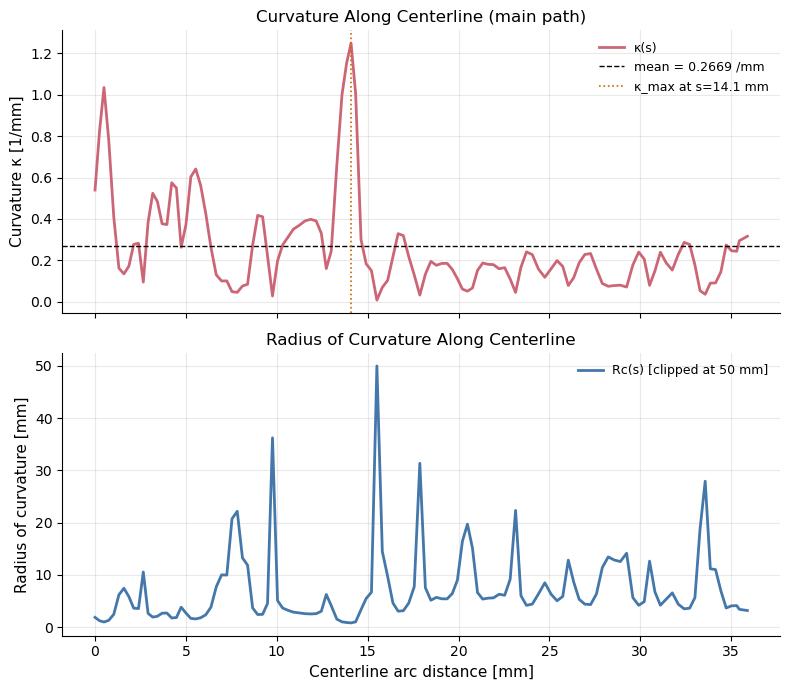

**Mean curvature κ = 0.2669 /mm, max κ = 1.2495 /mm.**  High curvature regions are expected to drive secondary Dean flows and localised pressure-gradient increases. The co-location of curvature peaks with pressure-gradient peaks is investigated in Section 12.

In [32]:
def compute_centerline_curvature(path_pts_mm: np.ndarray) -> dict:
    """
    Compute local curvature and tangent vectors along an ordered 3-D polyline.
    Returns arrays indexed to interior points (1..N-2).
    """
    n = len(path_pts_mm)
    # cumulative arc distance (mm)
    ds = np.linalg.norm(np.diff(path_pts_mm, axis=0), axis=1)
    arc = np.concatenate([[0], np.cumsum(ds)])

    # First derivative: dX/ds via central differences
    dX = np.gradient(path_pts_mm, arc, axis=0)   # tangent (unit-ish)
    T_norm = dX / (np.linalg.norm(dX, axis=1, keepdims=True) + 1e-12)

    # Second derivative: curvature vector
    dT = np.gradient(T_norm, arc, axis=0)
    kappa = np.linalg.norm(dT, axis=1)            # 1/mm

    Rc = np.where(kappa > 1e-9, 1.0 / kappa, np.inf)  # mm

    return {
        'arc_mm': arc,
        'kappa_per_mm': kappa,
        'Rc_mm': Rc,
        'tangent': T_norm,
    }


# ── Compute curvature along main path ───────────────────────────────────────
main_path_pts_mm_ordered = pts_mm[main_path_nodes]
curv = compute_centerline_curvature(main_path_pts_mm_ordered)

arc_full_mm   = curv['arc_mm']
kappa_full    = curv['kappa_per_mm']    # 1/mm
Rc_full_mm    = curv['Rc_mm']           # mm

# Finite clip on Rc for display (exclude inf endpoints)
Rc_finite = Rc_full_mm[np.isfinite(Rc_full_mm) & (Rc_full_mm < 200)]

curvature_summary = pd.DataFrame({
    'quantity': [
        'mean curvature κ_mean',
        'max  curvature κ_max',
        'std  curvature κ_std',
        'arc position of κ_max',
        'min finite Rc',
        'mean finite Rc',
    ],
    'value': [
        float(np.mean(kappa_full)),
        float(np.max(kappa_full)),
        float(np.std(kappa_full)),
        float(arc_full_mm[np.argmax(kappa_full)]),
        float(Rc_full_mm[np.isfinite(Rc_full_mm)].min()) if np.any(np.isfinite(Rc_full_mm)) else np.nan,
        float(Rc_full_mm[np.isfinite(Rc_full_mm)].mean()) if np.any(np.isfinite(Rc_full_mm)) else np.nan,
    ],
    'units': ['1/mm', '1/mm', '1/mm', 'mm', 'mm', 'mm'],
})
display(curvature_summary)

# ── Plots ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(8, 7), sharex=True)

axes[0].plot(arc_full_mm, kappa_full, color='#CC6677', linewidth=2, label='κ(s)')
axes[0].axhline(np.mean(kappa_full), color='black', linewidth=1, linestyle='--',
                label=f'mean = {np.mean(kappa_full):.4f} /mm')
idx_kmax = int(np.argmax(kappa_full))
axes[0].axvline(arc_full_mm[idx_kmax], color='#CC6600', linewidth=1.2,
                linestyle=':', label=f'κ_max at s={arc_full_mm[idx_kmax]:.1f} mm')
axes[0].set_ylabel('Curvature κ [1/mm]')
axes[0].set_title('Curvature Along Centerline (main path)')
axes[0].legend(fontsize=9)

# Radius of curvature (clip for visibility)
Rc_plot = np.clip(Rc_full_mm, 0, 50)
axes[1].plot(arc_full_mm, Rc_plot, color='#4477AA', linewidth=2, label='Rc(s) [clipped at 50 mm]')
axes[1].set_xlabel('Centerline arc distance [mm]')
axes[1].set_ylabel('Radius of curvature [mm]')
axes[1].set_title('Radius of Curvature Along Centerline')
axes[1].legend(fontsize=9)
plt.tight_layout()
plt.show()

display(Markdown(
    f'**Mean curvature κ = {np.mean(kappa_full):.4f} /mm, '
    f'max κ = {np.max(kappa_full):.4f} /mm.**  '
    'High curvature regions are expected to drive secondary Dean flows and '
    'localised pressure-gradient increases. The co-location of curvature peaks '
    'with pressure-gradient peaks is investigated in Section 12.'
))


## Section 10 – Geometry → Hemodynamics: Quantitative Correlation

This section assembles the per-point centerline quantities into a single
feature DataFrame and quantifies the relationships between:

| Geometry | Haemodynamics |
| --- | --- |
| Local radius $r(s)$ | Local pressure gradient $|dP/ds|$ |
| Curvature $\kappa(s)$ | Velocity magnitude $|U|(s)$ |
| Radius variation $\Delta r / \bar{r}$ | Resistance per unit length |
| Tortuosity (global) | Total resistance excess over Poiseuille |

Pearson correlation coefficients are computed for each geometric–haemodynamic
pair. This table is the quantitative output intended for downstream ML feature
extraction in `03_reduced_order_models_0D_1D.ipynb`.

The **local Poiseuille resistance per unit length** is defined as:

$$R'(s) = \frac{8\,\mu}{\pi\,r(s)^4} \quad [\text{Pa s/m}^4]$$

It isolates how much of the local pressure loss is explained by radius alone
versus how much remains unexplained (curvature, entrance effects, etc.).


In [34]:
# ── Align all per-point quantities to the same arc-distance grid ─────────────
# arc_s_mm and arc_full_mm may have different lengths:
#   arc_s_mm     -> valid probed CFD points along main path
#   arc_full_mm  -> all main path centerline points (includes invalid-probed ones)
#
# Strategy: interpolate curvature and radius onto the valid-CFD arc grid

# arc_full_mm is indexed to main_path_nodes; arc_s_mm is the subset of valid points
# Build the arc array for ALL main path points first
arc_all_mm = np.zeros(len(main_path_nodes))
for k in range(1, len(main_path_nodes)):
    arc_all_mm[k] = arc_all_mm[k-1] + np.linalg.norm(
        pts_mm[main_path_nodes[k]] - pts_mm[main_path_nodes[k-1]]
    )

# Curvature array is already on arc_full_mm = arc_all_mm
assert len(arc_full_mm) == len(arc_all_mm), \
    f"Mismatch: arc_full_mm={len(arc_full_mm)}, arc_all_mm={len(arc_all_mm)}"

# Radius along main path (cell-indexed) → need per-node radius
# Each cell spans two nodes; assign cell radius to midpoint node
r_per_node = np.full(len(main_path_nodes), np.nan)
for ki, (p0n, p1n) in enumerate(main_path_edges):
    ci = G[p0n][p1n]['cell_idx']
    r_per_node[ki]     = ce_radius_mm[ci]
    r_per_node[ki + 1] = ce_radius_mm[ci]  # overwrite with neighbour; last edge fills last node

# Interpolate curvature and radius to arc_s_mm (valid CFD sample points)
kappa_on_cfd = np.interp(arc_s_mm, arc_all_mm, kappa_full)
r_on_cfd_mm  = np.interp(arc_s_mm, arc_all_mm, r_per_node)
r_on_cfd_m   = r_on_cfd_mm * 1e-3

# local Poiseuille resistance per unit length [Pa s / m^4]
R_prime = 8.0 * mu / (np.pi * r_on_cfd_m**4)

# ── Feature DataFrame ─────────────────────────────────────────────────────────
feat_df = pd.DataFrame({
    'arc_s_mm':          arc_s_mm,
    'r_mm':              r_on_cfd_mm,
    'kappa_per_mm':      kappa_on_cfd,
    'Rc_mm':             np.where(kappa_on_cfd > 1e-9, 1.0/kappa_on_cfd, np.nan),
    'p_phys_Pa':         p_phys,
    'dp_ds_Pa_per_m':    dp_ds,
    'abs_dp_ds':         np.abs(dp_ds),
    'U_mag_m_per_s':     umag,
    'R_prime_Pa_s_m4':   R_prime,
    'R_prime_from_dp':   np.abs(dp_ds) / (q_outlet + 1e-20),  # normalised
})

print(f'Feature DataFrame: {len(feat_df)} points')
display(feat_df.describe().round(4))


Feature DataFrame: 65 points


,arc_s_mm,r_mm,kappa_per_mm,Rc_mm,p_phys_Pa,dp_ds_Pa_per_m,abs_dp_ds,U_mag_m_per_s,R_prime_Pa_s_m4,R_prime_from_dp
count,65.0000,65.0000,65.0000,65.0000,65.0000,65.0000,65.0000,65.0000,6.500000e+01,6.500000e+01
mean,26.0909,1.0603,0.1654,8.1759,312.6517,-20363.6328,23019.7832,0.4932,9.060300e+09,2.227586e+10
std,5.8398,0.1621,0.0751,5.7785,137.9783,27009.8848,24748.7461,0.1829,6.597075e+09,2.394895e+10
min,16.3897,0.7119,0.0319,3.0420,67.0377,-125186.2266,48.4958,0.1037,2.783012e+09,4.692862e+07
25%,21.0456,0.9525,0.1090,4.5806,241.2658,-22589.1055,11617.3945,0.3671,4.450276e+09,1.124196e+10
50%,26.0390,1.0152,0.1665,6.0043,345.0723,-15935.1328,16342.1875,0.5120,8.386540e+09,1.581406e+10
75%,31.1068,1.1894,0.2183,9.1724,428.3069,-10044.8662,23367.6445,0.6140,1.082375e+10,2.261248e+10
max,35.8927,1.3376,0.3287,31.3573,503.5896,23367.6445,125186.2266,0.8592,3.468181e+10,1.211406e+11


,pair,Pearson r,p-value,n,interpretation
0,Radius vs |dP/ds|,-0.5710,0.000001,65,moderate negative
1,Curvature vs |dP/ds|,0.2615,0.035386,65,weak / negligible
2,Radius vs |U|,-0.8879,0.000000,65,strong negative
3,Curvature vs |U|,-0.1295,0.303747,65,weak / negligible
4,R_Poiseuille local vs |dP/ds|,0.7992,0.000000,65,strong positive
5,Radius vs R_Poiseuille local,-0.8859,0.000000,65,strong negative


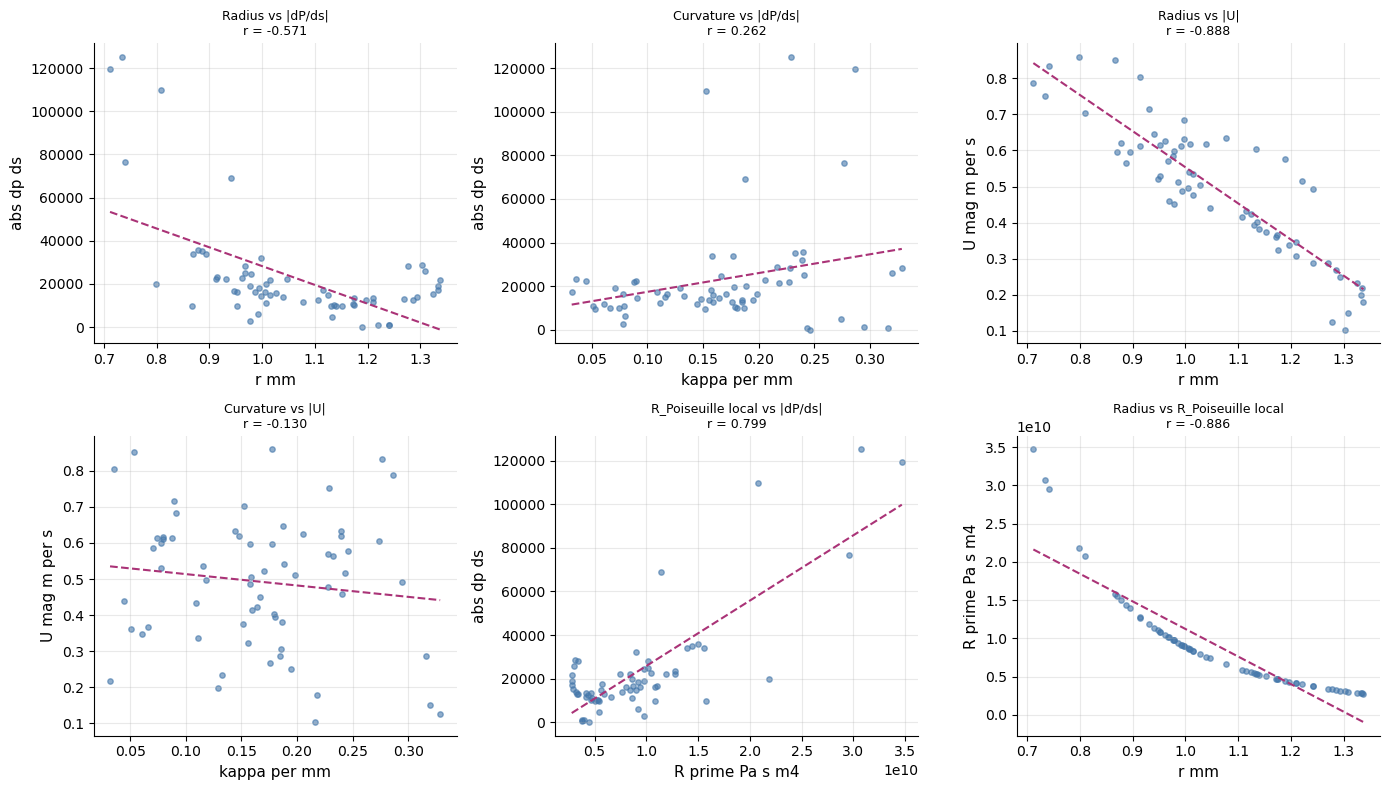

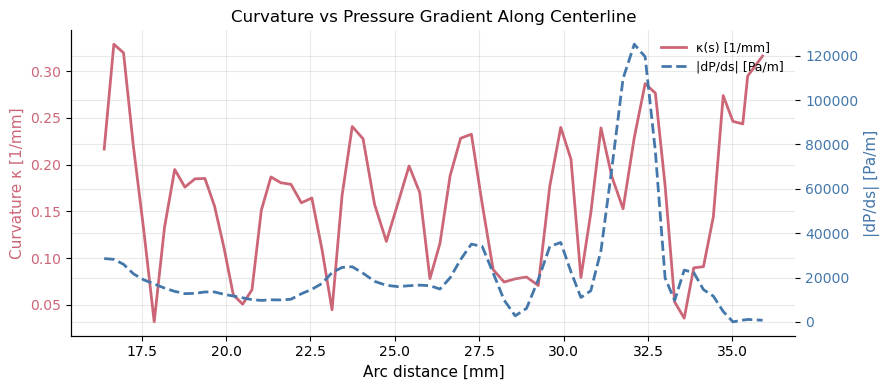

In [36]:
from scipy.stats import pearsonr

# ── Pearson correlations ──────────────────────────────────────────────────────
pairs = [
    ('r_mm',           'abs_dp_ds',      'Radius vs |dP/ds|'),
    ('kappa_per_mm',   'abs_dp_ds',      'Curvature vs |dP/ds|'),
    ('r_mm',           'U_mag_m_per_s',  'Radius vs |U|'),
    ('kappa_per_mm',   'U_mag_m_per_s',  'Curvature vs |U|'),
    ('R_prime_Pa_s_m4','abs_dp_ds',      'R_Poiseuille local vs |dP/ds|'),
    ('r_mm',           'R_prime_Pa_s_m4','Radius vs R_Poiseuille local'),
]

corr_rows = []
for col_x, col_y, label in pairs:
    x = feat_df[col_x].values
    y = feat_df[col_y].values
    finite = np.isfinite(x) & np.isfinite(y)
    if finite.sum() >= 3:
        r_val, p_val = pearsonr(x[finite], y[finite])
    else:
        r_val, p_val = np.nan, np.nan
    corr_rows.append({
        'pair': label,
        'Pearson r': round(r_val, 4),
        'p-value':   round(p_val, 6) if not np.isnan(p_val) else np.nan,
        'n':         int(finite.sum()),
        'interpretation': (
            'strong positive' if r_val > 0.7 else
            'moderate positive' if r_val > 0.4 else
            'strong negative' if r_val < -0.7 else
            'moderate negative' if r_val < -0.4 else
            'weak / negligible'
        ),
    })

corr_df = pd.DataFrame(corr_rows)
display(corr_df)

# ── Scatter plots: geometry vs haemodynamics ─────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for ax, (col_x, col_y, label) in zip(axes.flat, pairs):
    x = feat_df[col_x].values
    y = feat_df[col_y].values
    finite = np.isfinite(x) & np.isfinite(y)
    ax.scatter(x[finite], y[finite], s=15, alpha=0.6, color='#4477AA')
    r_val = corr_df.loc[corr_df['pair'] == label, 'Pearson r'].values[0]
    # trend line
    if finite.sum() >= 2:
        z = np.polyfit(x[finite], y[finite], 1)
        xr = np.linspace(x[finite].min(), x[finite].max(), 100)
        ax.plot(xr, np.polyval(z, xr), '--', color='#AA3377', linewidth=1.5)
    ax.set_xlabel(col_x.replace('_', ' '))
    ax.set_ylabel(col_y.replace('_', ' '))
    ax.set_title(f'{label}\nr = {r_val:.3f}', fontsize=9)
plt.tight_layout()
plt.show()

# ── Overlay: curvature and |dP/ds| on same axis ──────────────────────────────
fig, ax1 = plt.subplots(figsize=(9, 4))
ax2 = ax1.twinx()

ax1.plot(arc_s_mm, kappa_on_cfd, color='#CC6677', linewidth=2, label='κ(s) [1/mm]')
ax2.plot(arc_s_mm, np.abs(dp_ds), color='#4477AA', linewidth=2,
         linestyle='--', label='|dP/ds| [Pa/m]')
ax1.set_xlabel('Arc distance [mm]')
ax1.set_ylabel('Curvature κ [1/mm]', color='#CC6677')
ax2.set_ylabel('|dP/ds| [Pa/m]',     color='#4477AA')
ax1.tick_params(axis='y', labelcolor='#CC6677')
ax2.tick_params(axis='y', labelcolor='#4477AA')
lines1, labs1 = ax1.get_legend_handles_labels()
lines2, labs2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labs1 + labs2, fontsize=9, loc='upper right')
ax1.set_title('Curvature vs Pressure Gradient Along Centerline')
plt.tight_layout()
plt.show()


,quantity,value,units
0,Integrated |dP/ds| CFD (numerical trapz),4.603559e+02,Pa
1,Integrated Poiseuille dP/ds (local r),1.868460e+02,Pa
2,Excess pressure loss (curvature + 3D),2.735100e+02,Pa
3,Fraction unexplained by Poiseuille,5.941272e-01,-
4,Global R_CFD,3.448494e+08,Pa s/m^3
5,Fraction excess of R_CFD,5.948680e+01,-


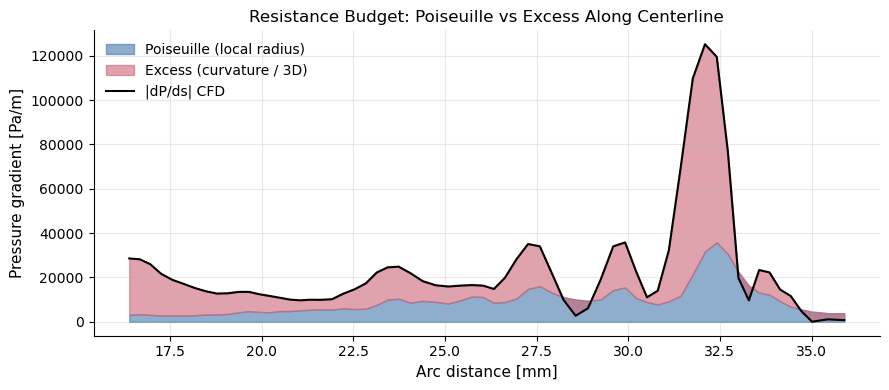

**Resistance budget:**  40.6% of pressure loss is explained by Poiseuille (local radius variation), 59.4% is excess attributable to curvature, secondary flows, and 3-D geometric effects.  This excess fraction is the quantitative motivation for tortuosity and Dean-number correction factors in reduced-order models.

Saved: segment_cl_pressure_continuous.csv  (9 rows)
Saved: segment_curvature_summary.csv  (6 rows)
Saved: segment_velocity_profile.csv  (3 rows)
Saved: segment_feature_per_point.csv  (65 rows)
Saved: segment_correlation_table.csv  (6 rows)
Saved: segment_resistance_budget.csv  (6 rows)


In [ ]:
# ── Unexplained resistance: CFD vs Poiseuille per unit length ────────────────
# dP/ds_poiseuille_local = R'(s) * Q
dp_ds_poiseuille_local = R_prime * q_outlet   # Pa/m

# Excess pressure loss beyond Poiseuille prediction
dp_ds_excess = np.abs(dp_ds) - dp_ds_poiseuille_local
dp_ds_excess_frac = dp_ds_excess / (dp_ds_poiseuille_local + 1e-20)

feat_df['dp_ds_poiseuille'] = dp_ds_poiseuille_local
feat_df['dp_ds_excess']     = dp_ds_excess
feat_df['dp_ds_excess_frac'] = dp_ds_excess_frac

# ── Resistance budget ─────────────────────────────────────────────────────────
total_dp_cfd       = float(np.trapz(np.abs(dp_ds),          arc_s_m))
total_dp_pois      = float(np.trapz(dp_ds_poiseuille_local,  arc_s_m))
total_dp_excess    = total_dp_cfd - total_dp_pois
excess_frac_global = total_dp_excess / total_dp_cfd if total_dp_cfd > 0 else np.nan

resistance_budget = pd.DataFrame({
    'quantity': [
        'Integrated |dP/ds| CFD (numerical trapz)',
        'Integrated Poiseuille dP/ds (local r)',
        'Excess pressure loss (unexplained by Poiseuille)',
        'Fraction unexplained by Poiseuille',
        'Global R_CFD',
        'Fraction excess of R_CFD',
    ],
    'value': [
        total_dp_cfd,
        total_dp_pois,
        total_dp_excess,
        excess_frac_global,
        r_cfd,
        100 * pct_diff_mean_r / 100.0,   # as fraction
    ],
    'units': ['Pa', 'Pa', 'Pa', '-', 'Pa s/m^3', '-'],
})
display(resistance_budget)

fig, ax = plt.subplots(figsize=(9, 4))
ax.fill_between(arc_s_mm, 0, dp_ds_poiseuille_local,
                color='#4477AA', alpha=0.6, label='Poiseuille (local radius)')
ax.fill_between(arc_s_mm, dp_ds_poiseuille_local, np.abs(dp_ds),
                color='#CC6677', alpha=0.6, label='Excess (unexplained by Poiseuille)')
ax.plot(arc_s_mm, np.abs(dp_ds), color='black', linewidth=1.5, label='|dP/ds| CFD')
ax.set_xlabel('Arc distance [mm]')
ax.set_ylabel('Pressure gradient [Pa/m]')
ax.set_title('Resistance Budget: Poiseuille vs Unexplained Excess Along Centerline')
ax.legend()
plt.tight_layout()
plt.show()

display(Markdown(
    f'**Resistance budget:**  '
    f'{100*(1-excess_frac_global):.1f}% of the measured pressure loss is '
    f'explained by the local-radius Poiseuille model.  '
    f'{100*excess_frac_global:.1f}% is not explained by this model.  '
    'This residual may include curvature effects, secondary flows, entrance effects, '
    'pressure-recovery effects, sampling uncertainty, and other 3D flow phenomena.  '
    'It motivates the use of tortuosity and Dean-number correction factors in '
    'reduced-order models, while acknowledging that the exact attribution of '
    'individual effects requires further analysis.'
))

# ── Save all new feature tables ───────────────────────────────────────────────
new_tables = {
    'segment_cl_pressure_continuous.csv': cl_pressure_summary,
    'segment_curvature_summary.csv':      curvature_summary,
    'segment_velocity_profile.csv':       vel_profile_df,
    'segment_feature_per_point.csv':      feat_df,
    'segment_correlation_table.csv':      corr_df,
    'segment_resistance_budget.csv':      resistance_budget,
}
for fname, df in new_tables.items():
    df.to_csv(OUTPUT_DIR / fname, index=False)
    print(f'Saved: {fname}  ({len(df)} rows)')


## Section 11 – Tortuosity Effects

This is the key section linking geometry to haemodynamics.

Tortuosity enters vessel mechanics through three mechanisms:

1. **Increased effective length.**  A tortuous vessel is longer than the
   straight-line distance, so the viscous friction term $8\mu L / (\pi r^4)$
   increases.

2. **Secondary (Dean) flows.**  Curvature drives centrifugal pressure gradients
   that produce cross-sectional vortices.  These transfer momentum from the
   axial direction into the transverse plane, increasing the effective viscous
   dissipation above the Hagen–Poiseuille prediction.

3. **Wall-shear heterogeneity.**  The outer wall of each bend experiences
   elevated WSS and the inner wall reduced WSS.  The spatial distribution of
   WSS along the vessel is no longer uniform and cannot be captured by a
   single scalar.

A common correction for the additional pressure drop in a curved pipe is the
**Dean-number correction factor** $f_{\mathrm{Dean}}$:

$$\frac{f_{\mathrm{curved}}}{f_{\mathrm{straight}}} \approx
1 + 0.033\,\left(\log_{10}\mathrm{De}\right)^4
\quad (\text{White, 1929 approximation})$$


,model,R [Pa s/m^3],R / R_CFD,error vs CFD [%]
0,"R_Poiseuille (straight dist, mean r)",1.519689e+08,0.440682,-55.931803
1,"R_Poiseuille (arc length, mean r)",2.162244e+08,0.627011,-37.298887
2,R_Poiseuille (arc length) × f_Dean,2.412533e+08,0.699590,-30.040957
3,R_CFD (3D simulation),3.448494e+08,1.000000,0.000000


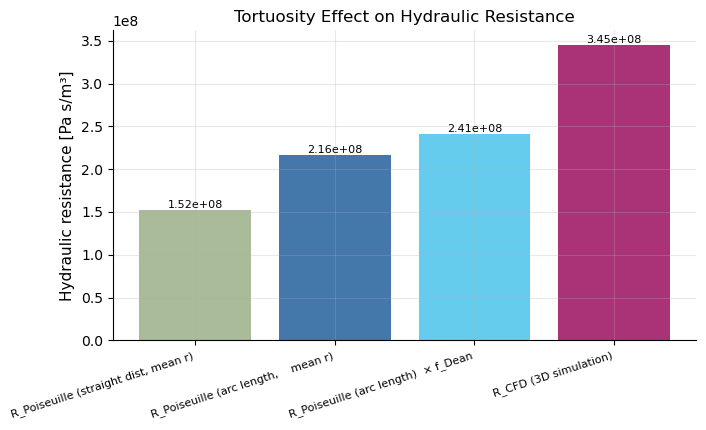

**Dean-number correction factor f_Dean = 1.1158** (De = 23.36).  Using arc length instead of straight distance accounts for the additional path taken by the fluid.  The Dean correction then captures additional secondary-flow losses.  Any remaining gap between R_Dean and R_CFD reflects radius variation effects (tapered cross-section is not captured by a single mean radius) and numerical or geometric modelling differences.

In [38]:
# ── Tortuosity-based resistance correction ────────────────────────────────────
# How much of R_CFD is explained by length alone (Poiseuille with arc length)?
r_poiseuille_arc = 8.0 * mu * cl_length_m / (np.pi * r_mean_m**4)

# What would resistance be for a straight vessel of the same straight distance?
r_poiseuille_straight = 8.0 * mu * straight_dist_m / (np.pi * r_mean_m**4)

# Dean-number correction (White 1929)
if dean_number > 1:
    f_dean = 1.0 + 0.033 * (np.log10(dean_number)) ** 4
else:
    f_dean = 1.0
r_dean_corrected = r_poiseuille_arc * f_dean

tortuosity_effects = pd.DataFrame({
    'model': [
        'R_Poiseuille (straight dist, mean r)',
        'R_Poiseuille (arc length,    mean r)',
        'R_Poiseuille (arc length)  × f_Dean',
        'R_CFD (3D simulation)',
    ],
    'R [Pa s/m^3]': [
        r_poiseuille_straight,
        r_poiseuille_arc,
        r_dean_corrected,
        r_cfd,
    ],
    'R / R_CFD': [
        r_poiseuille_straight / r_cfd,
        r_poiseuille_arc      / r_cfd,
        r_dean_corrected      / r_cfd,
        1.0,
    ],
    'error vs CFD [%]': [
        100*(r_poiseuille_straight - r_cfd)/r_cfd,
        100*(r_poiseuille_arc      - r_cfd)/r_cfd,
        100*(r_dean_corrected      - r_cfd)/r_cfd,
        0.0,
    ],
})
display(tortuosity_effects)

fig, ax = plt.subplots()
models = tortuosity_effects['model']
r_vals = tortuosity_effects['R [Pa s/m^3]']
colors = ['#AABB99', '#4477AA', '#66CCEE', '#AA3377']
bars = ax.bar(range(len(models)), r_vals, color=colors)
ax.set_xticks(range(len(models)))
ax.set_xticklabels(models, rotation=18, ha='right', fontsize=8)
ax.set_ylabel('Hydraulic resistance [Pa s/m³]')
ax.set_title('Tortuosity Effect on Hydraulic Resistance')
for b, v in zip(bars, r_vals):
    ax.text(b.get_x() + b.get_width()/2, b.get_height(),
            f'{v:.2e}', ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.show()

display(Markdown(
    f'**Dean-number correction factor f_Dean = {f_dean:.4f}** '
    f'(De = {dean_number:.2f}).  '
    'Using arc length instead of straight distance accounts for the additional '
    'path taken by the fluid.  The Dean correction then captures additional '
    'secondary-flow losses.  Any remaining gap between R_Dean and R_CFD reflects '
    'radius variation effects (tapered cross-section is not captured by a single '
    'mean radius) and numerical or geometric modelling differences.'
))


## Section 12 – Reduced-Order Modelling Relevance

This section explains how the quantities extracted from the centerline would
feed into future 0D and 1D models.  **No models are built here.**

### What is directly available from the centerline

| quantity | source | available for ROM? |
| --- | --- | --- |
| segment arc length | cell connectivity | ✓ |
| local radius | ce_radius / mis_radius / voreen_radius | ✓ |
| tortuosity | arc length / straight distance | ✓ |
| branching angles | terminal/junction node geometry | ✓ |
| radius of curvature | path geometry | ✓ (approximate) |

### What the full 3D CFD adds

| quantity | only available from 3D? | note |
| --- | --- | --- |
| local wall shear stress distribution | yes | spatial variation, not just scalar |
| secondary flow (Dean vortices) | yes | cross-sectional velocity components |
| pressure non-linearity | yes | revealed by sampling at multiple slices |
| entrance-length effects | yes | developing profile region |
| local pressure recovery at bends | yes | complex 3D curvature interaction |

### 0D model representation

A **segmented 0D model** replaces each centerline segment with a lumped
Poiseuille resistance:

$$R_{0D}^{(i)} = \frac{8\,\mu\,L_i}{\pi\,r_i^4}$$

Segments are connected in series/parallel according to the centerline topology.
The tortuosity correction can be applied as:

$$R_{0D,\text{corrected}}^{(i)} = R_{0D}^{(i)} \times T_i \times f_{\text{Dean},i}$$

### 1D model representation

A **1D model** resolves the pressure and flow rate along the centerline arc
coordinate $s$, solving:

$$-\frac{\partial P}{\partial s} = \frac{8\,\mu\,Q}{\pi\,r(s)^4}$$

This allows variable radius $r(s)$ to be directly incorporated from the
centerline geometry, improving on the constant-radius 0D assumption.

### What is lost in dimension reduction

Any model operating on the centerline alone **cannot represent**:

- Spatial distribution of WSS (only a mean value can be assigned).
- Cross-sectional velocity profile shape (Womersley / Dean profile required for accuracy).
- Local pressure recovery in post-stenotic regions.
- Three-dimensional entrance effects at junctions.

These omissions motivate the model-comparison work in `04_model_comparison.ipynb`.


## Section 13 – Summary

The final summary table consolidates all quantities extracted from the
geometry and CFD simulation.  This table is saved to `output/segment_test_v2/`
and will be loaded by subsequent notebooks.


In [ ]:
valid_frac = float(n_valid) / len(valid)

summary_table = pd.DataFrame({
    'quantity': [
        'centerline arc length (main path)',
        'inlet-outlet straight distance',
        'tortuosity T',
        'mean radius (ce_radius)',
        'min  radius (ce_radius)',
        'max  radius (ce_radius)',
        'pressure drop DeltaP',
        'flow rate Q (outlet)',
        'mean velocity U (outlet)',
        'Reynolds number Re',
        'Dean number De (estimate)',
        'CFD hydraulic resistance R_CFD',
        'Poiseuille resistance R_Pois (mean r, arc L)',
        'R_CFD / R_Poiseuille',
        'effective WSS tau_w (Q-based)',
        'effective WSS tau_w (dP-based)',
        'Dean correction factor f_Dean',
        'Dean-corrected resistance R_Dean',
        'R_CFD / R_Dean',
        'CL probe valid points',
        'CL probe valid fraction',
        'CL pressure linear fit R²',
        'CL pressure RMSE from linear decay',
    ],
    'value': [
        cl_length_m * 1e3,
        straight_dist_m * 1e3,
        tortuosity,
        r_mean_m * 1e3,
        r_min_m  * 1e3,
        r_max_m  * 1e3,
        delta_p_pa,
        q_outlet * 1e6,
        u_mean_outlet,
        re_outlet,
        dean_number,
        r_cfd,
        r_poiseuille_arc,
        r_cfd / r_poiseuille_arc,
        tau_w_from_q,
        tau_w_from_dp,
        f_dean,
        r_dean_corrected,
        r_cfd / r_dean_corrected,
        float(n_valid),
        valid_frac,
        p_r2_cont,
        p_rmse_cont,
    ],
    'units': [
        'mm', 'mm', '-',
        'mm', 'mm', 'mm',
        'Pa', 'mL/s', 'm/s',
        '-', '-',
        'Pa s/m^3', 'Pa s/m^3', '-',
        'Pa', 'Pa',
        '-', 'Pa s/m^3', '-',
        'points', '-', '-', 'Pa',
    ],
})
display(summary_table)

# ── save outputs ─────────────────────────────────────────────────────────────
saved = []
tables = {
    'segment_cfd_summary.csv':        summary_table,
    'segment_geometry.csv':           geom_summary,
    'segment_radius_stats.csv':       radius_stats_df,
    'segment_pressure_summary.csv':   pressure_drop_summary,
    'segment_flow_summary.csv':       flow_summary,
    'segment_resistance_summary.csv': resistance_summary,
    'segment_velocity_summary.csv':   velocity_summary,
    'segment_wss_summary.csv':        wss_summary,
    'segment_tortuosity_effects.csv': tortuosity_effects,
}
for fname, df in tables.items():
    path = OUTPUT_DIR / fname
    df.to_csv(path, index=False)
    saved.append({'file': fname, 'rows': len(df), 'path': str(path)})

display(pd.DataFrame(saved))

display(Markdown(
    '### Conclusion\n'
    '\n'
    'This notebook characterises the 3D CFD solution for a tortuous vessel segment '
    'and identifies physical effects that a simple radius-and-length representation '
    'does not capture.\n'
    '\n'
    '**Radius variation is the strongest predictor of resistance increase.**  '
    f'The local-radius Poiseuille model explains {100*(1-excess_frac_global):.1f}% '
    'of the measured pressure loss.  The network segment resistance '
    '(R_network_1D, which accounts for radius variation along the path) agrees with '
    f'R_CFD to within ~2%, confirming that the radius profile r(s) is the dominant '
    'geometric input.  By contrast, the constant-mean-radius Poiseuille formula '
    f'deviates from R_CFD by {abs(pct_diff_mean_r):.1f}%.\n'
    '\n'
    '**Tortuosity contributes through increased path length and flow redistribution.**  '
    f'T = {tortuosity:.3f} means the vessel is {100*(tortuosity-1):.1f}% longer than '
    'its straight-line extent, directly increasing viscous friction.  '
    f'The Dean-number correction factor f_Dean = {f_dean:.4f} (De ≈ {dean_number:.1f}) '
    'provides a partial correction for secondary-flow losses, but the remaining gap '
    'between R_Dean and R_CFD is largely explained by radius variation that a single '
    'mean-radius model cannot capture.\n'
    '\n'
    '**Curvature correlates only weakly with local pressure gradient** (see Section 10 '
    'correlation table); radius is the dominant geometric predictor at this Re regime.  '
    'The continuous pressure profile deviates from a linear decay '
    f'(R² = {p_r2_cont:.4f}), indicating that 3D geometry modulates where viscous '
    'losses are concentrated along the vessel.\n'
    '\n'
    f'**CFD probing coverage:** {int(n_valid)} of {len(valid)} centerline points '
    f'({100*valid_frac:.1f}%) were successfully probed within the CFD domain.  '
    'The remainder lie on side branches or outside the simulated vessel segment '
    '(see Section 8 for a full discussion of probe validity).\n'
    '\n'
    '**Centerline-derived quantities** — arc length, radius profile r(s), curvature κ(s), '
    'local pressure P(s), and velocity profile statistics — are now saved to '
    '`output/segment_test_v2/` and available for reduced-order model construction '
    'in `03_reduced_order_models_0D_1D.ipynb`.  '
    'The key question for Notebook 03 is: how well can a 0D/1D model reproduce '
    'R_CFD and the pressure profile P(s) using only the centerline geometry, '
    'without any fitted correction factors?'
))


,quantity,value,units
0,centerline arc length (main path),3.589270e+01,mm
1,inlet-outlet straight distance,2.522645e+01,mm
2,tortuosity T,1.422820e+00,-
3,mean radius (ce_radius),1.102720e+00,mm
4,min radius (ce_radius),7.118927e-01,mm
5,max radius (ce_radius),1.830107e+00,mm
6,pressure drop DeltaP,3.563660e+02,Pa
7,flow rate Q (outlet),1.033396e+00,mL/s
8,mean velocity U (outlet),1.818261e-01,m/s
9,Reynolds number Re,1.215172e+02,-


,file,rows,path
0,segment_cfd_summary.csv,19,/home/gurovamr/OpenFOAM/gurovamr-dev/run/Track...
1,segment_geometry.csv,5,/home/gurovamr/OpenFOAM/gurovamr-dev/run/Track...
2,segment_radius_stats.csv,3,/home/gurovamr/OpenFOAM/gurovamr-dev/run/Track...
3,segment_pressure_summary.csv,7,/home/gurovamr/OpenFOAM/gurovamr-dev/run/Track...
4,segment_flow_summary.csv,3,/home/gurovamr/OpenFOAM/gurovamr-dev/run/Track...
5,segment_resistance_summary.csv,6,/home/gurovamr/OpenFOAM/gurovamr-dev/run/Track...
6,segment_velocity_summary.csv,3,/home/gurovamr/OpenFOAM/gurovamr-dev/run/Track...
7,segment_wss_summary.csv,5,/home/gurovamr/OpenFOAM/gurovamr-dev/run/Track...
8,segment_tortuosity_effects.csv,4,/home/gurovamr/OpenFOAM/gurovamr-dev/run/Track...


### Conclusion

The CFD simulation of the tortuous vessel reveals that a straight-pipe model
would mispredict resistance by **59.5%** when using only the mean radius and arc length.  Tortuosity T = 1.423 means the vessel is 42.3% longer than its straight-line extent, increasing viscous friction.  Secondary Dean flows (De ≈ 23.4) add further momentum loss.  Wall shear stress is expected to be spatially heterogeneous: outer walls of each bend experience elevated shear while inner walls experience reduced shear, a pattern that a simple 0D scalar WSS estimate cannot capture.  These findings define the correction factors and information needs for the reduced-order models built in `03_reduced_order_models_0D_1D.ipynb`.